## Lg Q Analysis
Finding event specific source term and Q

In [1]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
import random
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import csv
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm
from scipy.signal import resample
from obspy import Stream
from matplotlib.colors import LogNorm

import pandas as pd
from shapely.geometry import box, LineString
from collections import defaultdict
from tqdm import tqdm
from new_functions import *

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
import warnings
warnings.filterwarnings("ignore")

5.7


/home/schreinl/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
existent_catalog_with_coords = []

datacenters = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC','BGR',"http://fdsnws.sismologia.ign.es"]
directory = '/home/schreinl/Stage/Data1/'
distmin = 0.5
distmax = 10.0
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
#catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
eq_list = catalogue_5
codawindow = 'cutoff'
factor = 1.1
fmin = [0.5,2,4,6]
fmax = [1.5,3,6,8]
counter = 0
for event in range(len(eq_list)):
    #print("event", event, "out of", len(eq_list))
    start = UTCDateTime(eq_list["time"][event]) - 25
    end = start + 700
    eq_lon = float(eq_list["longitude"][event])
    eq_lat = float(eq_list["latitude"][event])
    
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    existent = True
    for i in range(len(fmin)):
        amplitude_test = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_new_{codawindow}_fac_{factor}_{fmin[i]}_{fmax[i]}Hz_dict.txt"
        if os.path.exists(amplitude_test):
            counter += 1
            if eq_list["time"][event] not in [entry[0] for entry in existent_catalog_with_coords]:
                existent_catalog_with_coords.append((eq_list["time"][event], eq_lat, eq_lon))
        else:
            existent = False

latitudes = [entry[1] for entry in existent_catalog_with_coords]
longitudes = [entry[2] for entry in existent_catalog_with_coords]

event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

for time, lat, lon in existent_catalog_with_coords:
    popup_text = f"Event Time: {time}<br>Lat: {lat}, Lon: {lon}"
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        tooltip=popup_text,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=1
    ).add_to(event_map)


print(f'{len(existent_catalog_with_coords)} events with coordinates found.')
event_map


209 events with coordinates found.


#### Site term calculation

Here all the site terms are calculated, for different frequency bands, and one is plotted.

In [3]:
fmin = 2
fmax = 3
frequenciesmin = [0.5,2,4,6]
frequenciesmax = [1.5,3,6,8]
event_file='/home/schreinl/Stage/Data/big_box_4.5.csv'
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

#calculate the site terms 
dict_test = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", factor=1.1, fmin=fmin, fmax=fmax, data_dir='Data1',envelope_name='new')
ref_value_test = reference_stations_median(best_bet,event_file, fmin, fmax, envelope_name='new')
sites_effect_dict_test = site_effect_dict(event_file, fmin,fmax,best_bet,envelope_name='new')

site_effects = site_effect_overall(fmin, fmax, best_bet, frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax, method='multiple', map_plot=False, envelope_name='new')



output_path = "/home/schreinl/Stage/Data1/Site_effects_dict.txt"
with open(output_path, "w") as f:
    json.dump(site_effects, f, indent=4)

print(f"Site effects saved to {output_path}")

filtered_site_effects = {}
for freq_band, stations in site_effects.items():
    filtered_site_effects[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 5
    }

all_site_terms = {}
for freq_band, stations in site_effects.items():
    all_site_terms[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 0
    }

carte = map_site_effect(fmin, fmax, filtered_site_effects, method='multiple')
#carte.save(f"site_effect_{(fmin+fmax)/2}_Hz_map.html")
carte

Site effects saved to /home/schreinl/Stage/Data1/Site_effects_dict.txt
done reading in


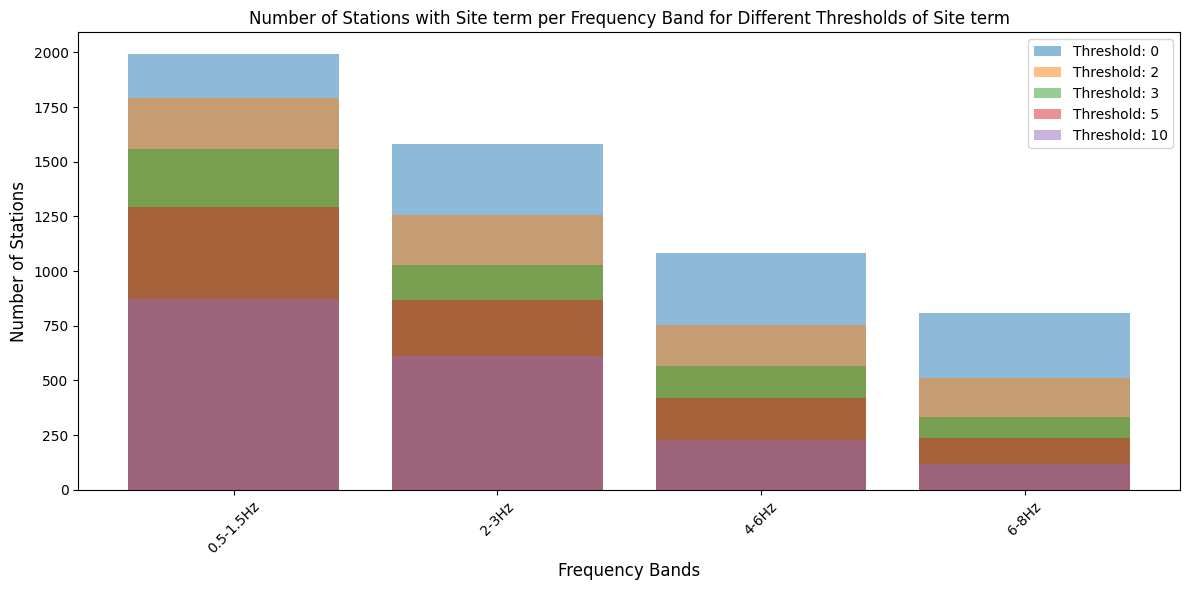

In [4]:
freqs = ['0.5-1.5Hz', '2-3Hz', '4-6Hz', '6-8Hz']
thresholds = [0,2, 3, 5, 10]
filtered_site_effects_by_threshold = {}

for threshold in thresholds:
    filtered_site_effects = {}
    for freq_band, stations in site_effects.items():
        filtered_site_effects[freq_band] = {
            station: data for station, data in stations.items() if data.get("num_points_after", 0) >= threshold
        }
    filtered_site_effects_by_threshold[threshold] = filtered_site_effects

# Plot histograms
plt.figure(figsize=(12, 6))
for threshold, filtered_site_effects in filtered_site_effects_by_threshold.items():
    amount = []
    for freq in freqs:
        amount.append(len(filtered_site_effects[freq]))
    plt.bar(freqs, amount, alpha=0.5, label=f'Threshold: {threshold}')

plt.xlabel('Frequency Bands', fontsize=12)
plt.ylabel('Number of Stations', fontsize=12)
plt.title('Number of Stations with Site term per Frequency Band for Different Thresholds of Site term')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


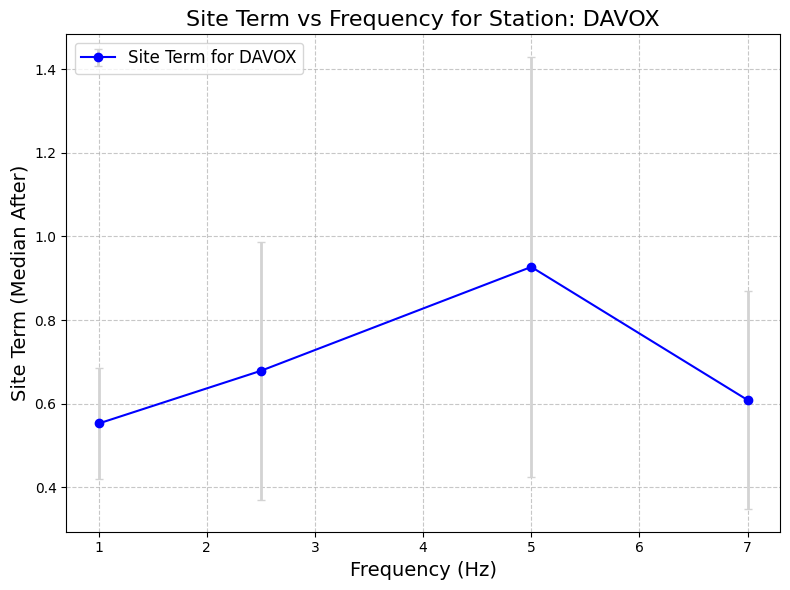

In [5]:
def plot_site_term_for_station(site_effects, station_name):
    frequencies = []
    site_terms = []
    std_devs = []

    for freq_band, stations in site_effects.items():
        if station_name in stations:
            freq_min, freq_max = map(float, freq_band.replace('Hz', '').split('-'))
            center_frequency = (freq_min + freq_max) / 2
            frequencies.append(center_frequency)
            site_terms.append(stations[station_name].get("median_after", None))
            std_devs.append(stations[station_name].get("std_after", 0))  # Default std to 0 if not available

    if not frequencies:
        print(f"No data found for station '{station_name}' in the site effects dictionary.")
        return

    plt.figure(figsize=(8, 6))
    plt.errorbar(frequencies, site_terms, yerr=std_devs, fmt='o', linestyle='-', color='blue', 
                 ecolor='lightgray', elinewidth=2, capsize=3, label=f'Site Term for {station_name}')
    plt.xlabel('Frequency (Hz)', fontsize=14)
    plt.ylabel('Site Term (Median After)', fontsize=14)
    plt.title(f'Site Term vs Frequency for Station: {station_name}', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

station_name = "DAVOX"
plot_site_term_for_station(site_effects, station_name)

In [12]:
def print_keys(d, indent=''):
    for key, value in d.items():
        print(indent + str(key))
        if isinstance(value, dict):
            print_keys(value, indent + '  ')

print_keys(site_effects)


0.5-1.5Hz
  GRA
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  BETS
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  ILLK
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  OPS
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  AGO
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  BALS
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  BARI
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  BETHI
    median_before
    std_before
    num_points_before
    median_after
    std_after
    num_points_after
  BOUC
    median_before
    std_before
    num_points_before
    median_after
 

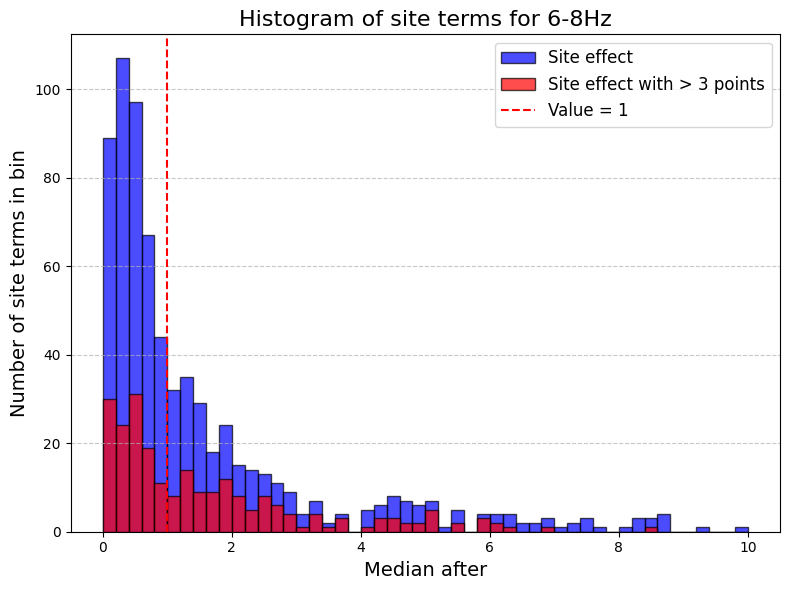

In [6]:



def plot_histogram_for_frequency_range(site_effects, frequency_range, second_site_effect=None,threshold=5, value_key='median_after', bins=20, value_range=None):
    if frequency_range not in site_effects:
        print(f"Frequency range '{frequency_range}' not found in the dictionary.")
        return

    values = []
    for station, station_data in site_effects[frequency_range].items():
        if value_key in station_data:
            values.append(station_data[value_key])
    second_values = []
    if second_site_effect:
        for station, station_data in second_site_effect[frequency_range].items():
            if value_key in station_data:
                second_values.append(station_data[value_key])

    if not values:
        print(f"No '{value_key}' values found for frequency range '{frequency_range}'.")
        return
    
    if not second_site_effect:
        plt.figure(figsize=(8, 6))
        plt.hist(values, range=value_range, bins=bins, color='blue', alpha=0.7, edgecolor='black')
        plt.axvline(x=1, color='red', linestyle='--', label='Value = 1')
        plt.xlabel(value_key.replace('_', ' ').capitalize(), fontsize=14)
        plt.ylabel('Number of site terms in bin', fontsize=14)
        plt.title(f"Histogram of site terms for {frequency_range}", fontsize=16)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.legend(fontsize=12)
        plt.tight_layout()
        plt.show()
    elif second_site_effect:
        plt.figure(figsize=(8, 6))
        plt.hist(values, range=value_range, bins=bins, color='blue', alpha=0.7, edgecolor='black', label='Site effect')
        plt.hist(second_values, range=value_range, bins=bins, color='red', alpha=0.7, edgecolor='black', label=f'Site effect with > {threshold} points')
        plt.axvline(x=1, color='red', linestyle='--', label='Value = 1')
        plt.xlabel(value_key.replace('_', ' ').capitalize(), fontsize=14)
        plt.ylabel('Number of site terms in bin', fontsize=14)
        plt.title(f"Histogram of site terms for {frequency_range}", fontsize=16)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.legend(fontsize=12)
        plt.tight_layout()
        plt.show()




filtered_site_effects = {}
for freq_band, stations in site_effects.items():
    filtered_site_effects[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 5
    }


freq_band = '6-8Hz'
plot_histogram_for_frequency_range(site_effects, freq_band, second_site_effect=filtered_site_effects ,threshold = 3,value_key='median_after', bins=50, value_range=(0, 10))

In [33]:
#get the amplitudes of the Lg waves for all the frequency ranges

'''

from urllib.error import URLError
from http.client import HTTPException
import os
import warnings
warnings.filterwarnings("ignore")

datacenters = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC','BGR',"http://fdsnws.sismologia.ign.es"]
directory = '/home/schreinl/Stage/Data1/'
distmin = 0.5
distmax = 10.0
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
eq_list = catalogue_5
codawindow = 'cutoff'
factor = 1.1
fmin = [0.5,2,4]
fmax = [1.5,3,6]

for event in range(len(eq_list)):
    print("event", event, "out of", len(eq_list))
    start = UTCDateTime(eq_list["time"][event]) -25
    end = start + 700
    eq_lon = float(eq_list["longitude"][event])
    eq_lat = float(eq_list["latitude"][event])
    
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    for i in range(len(fmin)):
        retry_attempts = 3
        
        for attempt in range(retry_attempts):
            try:
                st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
                break
            except (URLError, FDSNNoDataException, HTTPException) as e:
                print(f"Failed to download data for event {event} on attempt {attempt + 1}: {str(e)}")
                if attempt < retry_attempts - 1:
                    print("Retrying with a smaller time window...")
                    end -= 100  # Reduce the time window by 100 seconds and retry
                else:
                    print("Max retry attempts reached. Skipping event...")
                    break  # Exit the retry loop and skip the event




    for i in range(len(fmin)):
        print(f'Frequency range {fmin[i]}-{fmax[i]}')
        
        st_plot_filt_all = st_all.copy()
        st_plot_filt_all.filter("bandpass", freqmin=fmin[i], freqmax=fmax[i])


        snr_threshold = 5
        eq_start = start

        filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_test, filtered_st, stations_with_amps, amp_plot = SNR_all(
            stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min, vLg_max, vPg_min, vPg_max, tminCoda, tmaxCoda,
            Dtmin_Noise, Dtmax_Noise, eq_start, eq_lat, eq_lon, snr_threshold=snr_threshold, plot_SNR=False, plot_amps=True, wavecode="Lg_Coda", dB=True, codawindow=codawindow, factor=factor)

        if filtered_stations_with_SNR is None or len(filtered_stations_with_SNR) == 0:
            continue
        
        with open(f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_{fmin[i]}_{fmax[i]}Hz_{snr_threshold}_thresh_stations_with_amps.txt", "w") as ampls:
            json.dump(stations_with_amps.tolist(), ampls, indent=4)
'''

'\n\nfrom urllib.error import URLError\nfrom http.client import HTTPException\nimport os\nimport warnings\nwarnings.filterwarnings("ignore")\n\ndatacenters = [\'RESIF\', \'ODC\', \'ETH\', \'INGV\', \'GEOFON\', \'IRIS\', \'ICGC\',\'BGR\',"http://fdsnws.sismologia.ign.es"]\ndirectory = \'/home/schreinl/Stage/Data1/\'\ndistmin = 0.5\ndistmax = 10.0\ncatalogue_5 = pd.read_csv(\'/home/schreinl/Stage/Data/big_box_4.5.csv\')\neq_list = catalogue_5\ncodawindow = \'cutoff\'\nfactor = 1.1\nfmin = [0.5,2,4]\nfmax = [1.5,3,6]\n\nfor event in range(len(eq_list)):\n    print("event", event, "out of", len(eq_list))\n    start = UTCDateTime(eq_list["time"][event]) -25\n    end = start + 700\n    eq_lon = float(eq_list["longitude"][event])\n    eq_lat = float(eq_list["latitude"][event])\n    \n    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")\n    for i in range(len(fmin)):\n        retry_attempts = 3\n        \n        for attempt in range(retry_attempts):\n            try:\n  

#### Calculation of the Lg Amplitude of each seismogram for each event

In [97]:




def Lg_amplitude_dict(base_directory):
    events_data = {}

    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)

        if os.path.isdir(dir_path):
            event_stations = {} 
            for filename in os.listdir(dir_path):
                if filename.endswith("_5_thresh_stations_with_amps.txt"):
                    file_path = os.path.join(dir_path, filename)

                    with open(file_path, "r") as f:
                        data = json.load(f)

                    for entry in data:
                        network = entry[0]
                        station_name = entry[1]
                        amplitude = float(entry[12])
                        station_key = f"{network}.{station_name}"
                        event_stations[station_key] = amplitude

            events_data[timestamp_dir] = event_stations

    return events_data

base_directory = "/home/schreinl/Stage/Data1" 
Lg_dict = Lg_amplitude_dict(base_directory)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")






Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [98]:
import os
import json

def Lg_amplitude_dict(base_directory):
    events_data = {}

    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)

        if os.path.isdir(dir_path):
            event_stations = {} 
            for filename in os.listdir(dir_path):
                if filename.endswith("_5_thresh_stations_with_amps.txt"):
                    file_path = os.path.join(dir_path, filename)
                    with open(file_path, "r") as f:
                        data = json.load(f)

                    if isinstance(data, dict):
                        
                        if "stations" in data:
                            data = data["stations"]
                        else:
                            data = []

                    if isinstance(data, list):
                        for entry in data:
                            if isinstance(entry, list) and len(entry) > 12:
                                network = entry[0]
                                station_name = entry[1]
                                amplitude = float(entry[12])
                                station_key = f"{network}.{station_name}"
                                event_stations[station_key] = amplitude

            events_data[timestamp_dir] = event_stations

    return events_data

base_directory = "/home/schreinl/Stage/Data1" 
Lg_dict = Lg_amplitude_dict(base_directory)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")


Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [36]:
#this one correctly reads in the amplitudes for the different frequencies

def Lg_amplitude_dict(base_directory, fmin, fmax):
    events_data = {}
    
    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)
        
        if os.path.isdir(dir_path):
            event_stations = {}
            
            for f1, f2 in zip(fmin, fmax):
                frequency_range = f"{f1}_{f2}Hz" 
                filename = f"{timestamp_dir}_{frequency_range}_5_thresh_stations_with_amps.txt"
                file_path = os.path.join(dir_path, filename)
                
                if os.path.exists(file_path):
                    try:
                        with open(file_path, "r") as f:
                            data = json.load(f)
                        
                        if isinstance(data, list):
                            for entry in data:
                                if isinstance(entry, list) and len(entry) > 12:
                                    network = entry[0]
                                    station_name = entry[1]
                                    amplitude = float(entry[12])
                                    station_key = f"{network}.{station_name}"
                                    
                                    if station_key not in event_stations:
                                        event_stations[station_key] = {}
                                    
                                    event_stations[station_key][frequency_range] = amplitude
                        else:
                            print(f"Unexpected data format in file: {file_path}")
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
            
            if event_stations:
                events_data[timestamp_dir] = event_stations
    
    return events_data

fmin = [0.5, 2, 4, 6]  
fmax = [1.5,3, 6, 8] 

base_directory = "/home/schreinl/Stage/Data1"
Lg_dict = Lg_amplitude_dict(base_directory, fmin, fmax)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")


Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [99]:



# ln(A*r**0.83) - ln(Siteeffect) = ln(Sk) - pi*f*r/Q*V
#f being the center frequency, V the velocity of the Lg wave which can be taken as 3.1km/s
#create a dict that has for each event the amplitude of the Lg wave window for each station 




def Lg_amplitude_calculation(fmin,fmax,Lg_dict,savefile=False):


    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)


    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results = {}
    Q0_calculation_terms = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        #print(formatted_event_time)
        if formatted_event_time not in event_data:
            #print(f"Skipping event {formatted_event_time}: Not found in CSV")
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        event_results = {}
        tmp = {}
        for station, amplitude in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break
            
            if site_effect is None or site_effect <= 0:
                continue 
            #log_value = np.log(amplitude * (r ** 0.83)) - np.log(site_effect)
            log_value = np.log(amplitude) + (5/6)*np.log(r) - np.log(site_effect)
            event_results[station] = {"log_value": log_value, "distance_km": r}
            tmp[station] = {'amplitude': amplitude, 'distance': r, 'site_effect': site_effect}
        results[formatted_event_time] = event_results
        Q0_calculation_terms[formatted_event_time] = tmp

    results_with_coords = {}
    for event_time, event_results in results.items():
        event_lat, event_lon = event_data[event_time]
        results_with_coords[event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "data": event_results
        }
    if savefile:
        with open("../Data1/processed_event_amplitudes.txt", "w") as f:
            json.dump(results, f, indent=4)
        with open("../Data1/orocessed_event_amplitudes_coords.txt", "w") as g:
            json.dump(results_with_coords, g, indent=4)

    print("Processing complete.")
    return results, results_with_coords

In [100]:
base_directory = "/home/schreinl/Stage/Data1" 
#Lg_dict = Lg_amplitude_dict(base_directory,fmin,fmax)
fmin = 0.5
fmax = 1.5
results , results_with_coords= Lg_amplitude_calculation(fmin,fmax,Lg_dict,savefile=True)



Processing complete.


Intercept: -12.021386208680907
Slope: -0.0019073617611328616
for event 2011_09_25T13_17_10 the Q factor is 514.7149975701041


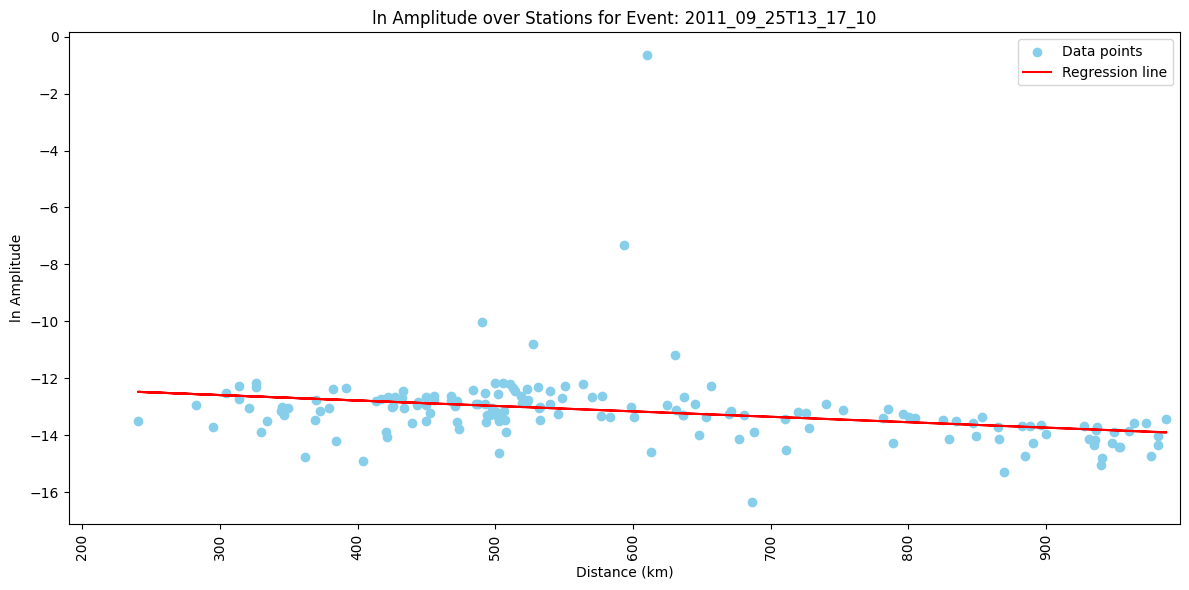

In [101]:
from scipy.stats import linregress
#event_time =  '2023_06_16T16_38_28'#  '2022_11_09T06_07_26'

event_time = list(results.keys())[40] 
event_data = results[event_time]

stations = list(event_data.keys())
log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
distances = [station_data["distance_km"] for station_data in event_data.values()]

filtered_distances = [d for d in distances if d > 200]
filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")
Q = -(np.pi*((fmin+fmax)/2)/(3.2*slope) )
print(f'for event {event_time} the Q factor is {Q}')
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
plt.plot(distances, intercept + slope * np.array(distances), color='red', label='Regression line')
plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190,max(filtered_distances)+10])
plt.title(f'ln Amplitude over Stations for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()




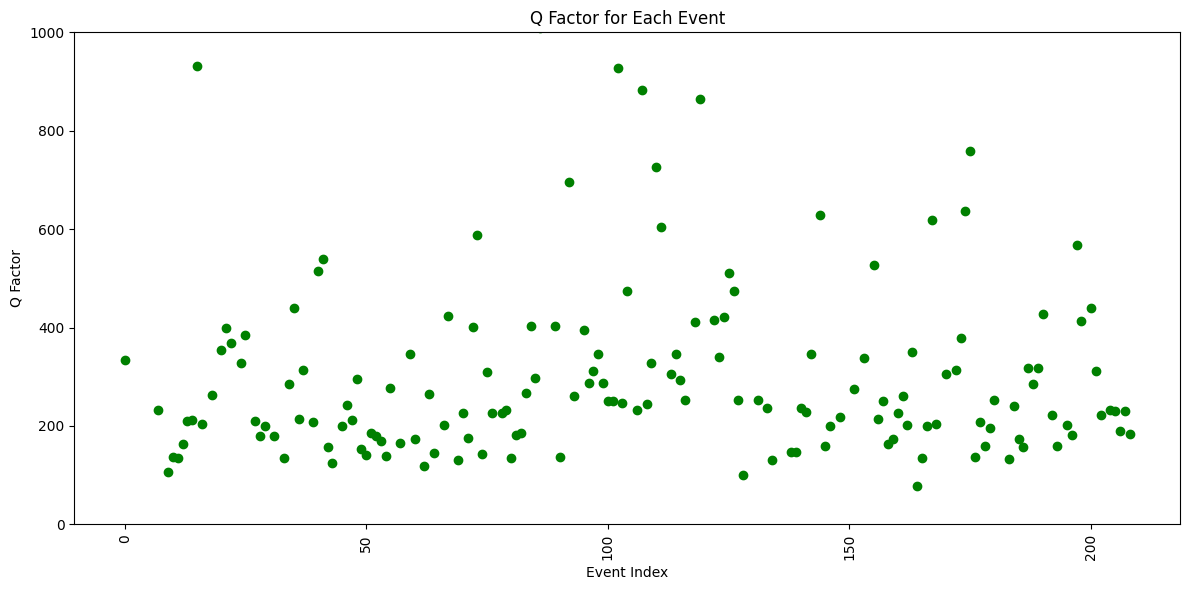

In [102]:


Q_values = {}

for event_time, event_data in results.items():
    stations = list(event_data.keys())
    log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
    distances = [station_data["distance_km"] for station_data in event_data.values()]

    # Filter out distance values less than or equal to 200 km
    filtered_distances = [d for d in distances if d > 200]
    filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

    if len(filtered_distances) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

        Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope))

        Q_values[event_time] = Q
        #this can be sometimes
        #plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
        #plt.plot(filtered_distances, intercept + slope * np.array(filtered_distances), color='red', label='Regression line')
        #plt.xlabel('Distance (km)')
        #plt.ylabel('ln Amplitude')
        #plt.title(f'ln Amplitude over Stations for Event: {event_time}')
        #plt.legend()
        #plt.xticks(rotation=90)
        #plt.tight_layout()
        #plt.show()
plt.figure(figsize=(12, 6))
plt.scatter(range(len(Q_values)), list(Q_values.values()), marker='o', color='green')
plt.xlabel('Event Index')
plt.ylim([0,1000])
plt.ylabel('Q Factor')
plt.title('Q Factor for Each Event')
plt.xticks(range(0, len(Q_values), 50), rotation=90)
plt.tight_layout()
plt.show()

#for event_time, Q in Q_values.items():
#    print(f"Event Time: {event_time}, Q: {Q}")


Processing complete.
Processed 209 events with Q0 and Sk values.


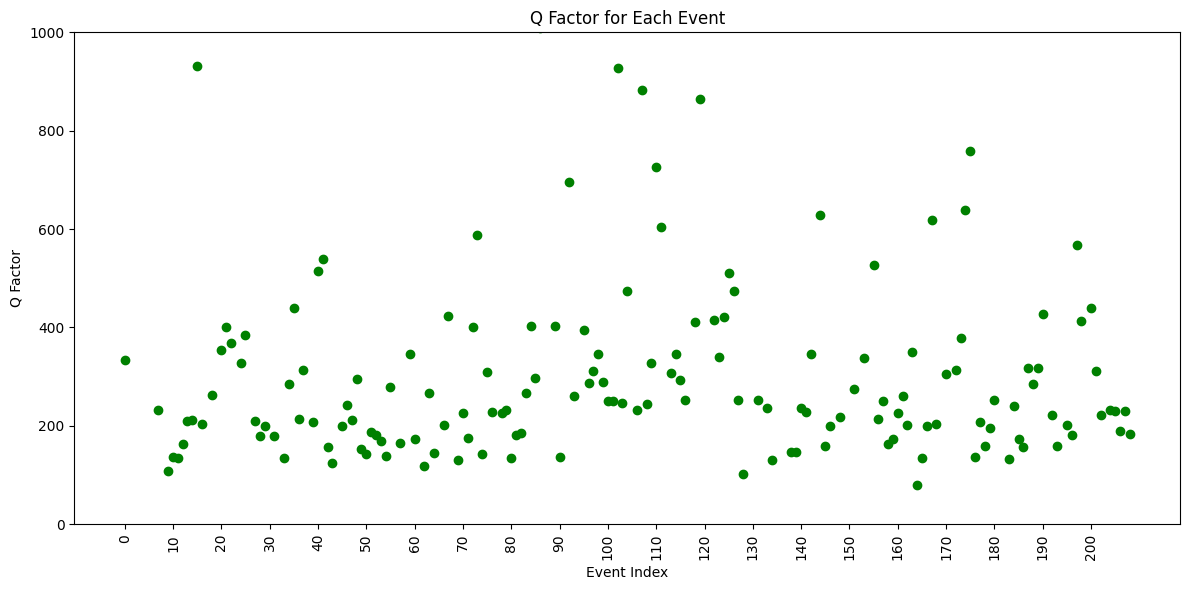

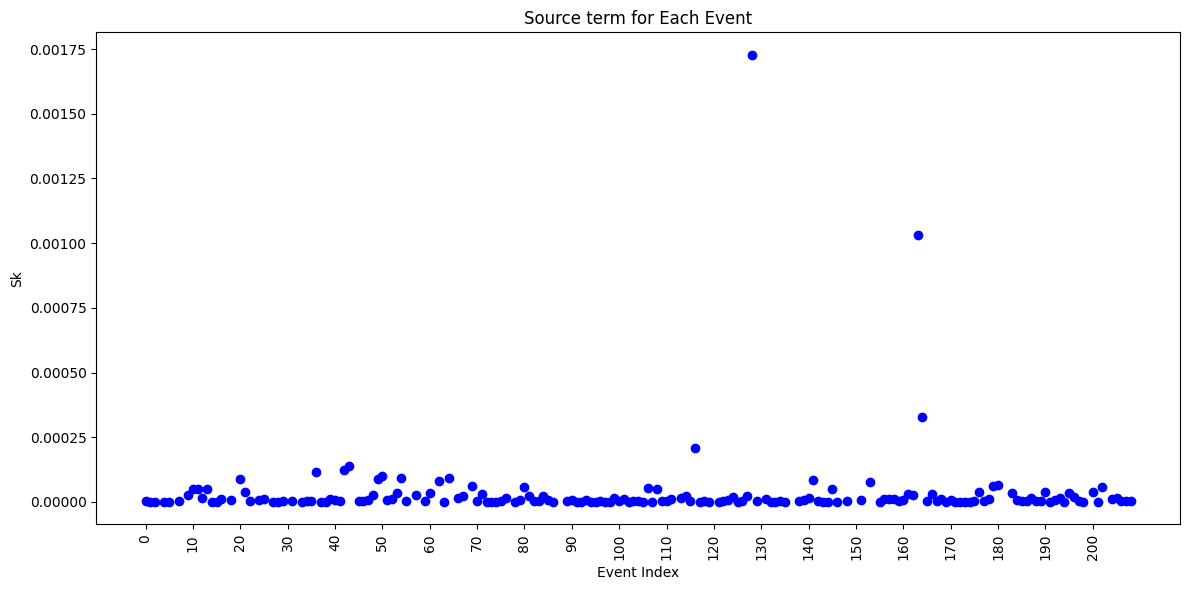

lower boundary -441.1405210477661 and upper boundary 867.4148577204717
177 events on map


In [103]:
def Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False, plot_Sk_map=False):
    base_directory = "/home/schreinl/Stage/Data1" 
    Lg_dict = Lg_amplitude_dict(base_directory)
    results, results_with_coords = Lg_amplitude_calculation(fmin, fmax, Lg_dict, savefile=False)

    event_data_dict = {}

    for event_time, event_data in results.items():
        log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
        distances = [station_data["distance_km"] for station_data in event_data.values()]

        filtered_distances = [d for d in distances if d > 200]
        filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]
        
        if len(filtered_distances) > 1:
            slope, intercept, _, _, _ = linregress(filtered_distances, filtered_log_amplitudes)
            Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope))
            Sk = np.exp(intercept)
            if event_time in results_with_coords:
                coordinates = results_with_coords[event_time]["coordinates"]
                event_data_dict[event_time] = {
                    "Q0": Q,
                    "Sk": Sk,
                    "coordinates": coordinates
                }

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")

    if plot_Q0 and event_data_dict:
        Q0_values = [data["Q0"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Q0_values)), Q0_values, marker='o', color='green')
        plt.xlabel('Event Index')
        plt.ylim([0, 1000])
        plt.ylabel('Q Factor')
        plt.title('Q Factor for Each Event')
        plt.xticks(range(0, len(Q0_values), max(1, len(Q0_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Sk and event_data_dict:
        Sk_values = [data["Sk"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Sk_values)), Sk_values, marker='o', color='blue')
        plt.xlabel('Event Index')
        plt.ylabel('Sk')
        plt.title('Source term for Each Event')
        plt.xticks(range(0, len(Sk_values), max(1, len(Sk_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Q0_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Q_values = [event_data["Q0"] for event_data in event_data_dict.values()]

        unique_Q_values = sorted(set(Q for Q in Q_values if not np.isnan(Q)))
        print(f'lower boundary {np.percentile(unique_Q_values,5)} and upper boundary {np.percentile(unique_Q_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Q_values,5), 
            vmax=np.percentile(unique_Q_values,95)
        )
        colormap.caption = "Q Factor"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Q = event_data["Q0"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Q):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Q:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Q),  # Use colormap with sorted values
                    weight=1,
                    fill=True,
                    fill_color=colormap(Q),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map
        

    if plot_Sk_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Sk_values = [event_data["Sk"] for event_data in event_data_dict.values()]

        unique_Sk_values = sorted(set(Sk for Sk in Sk_values if np.isfinite(Sk)))
        print(unique_Sk_values)
        print(f'lower boundary {np.percentile(unique_Sk_values,5)} and upper boundary {np.percentile(unique_Sk_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Sk_values,5), 
            vmax=np.percentile(unique_Sk_values,95)
        )
        colormap.caption = "Source Term"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Sk = event_data["Sk"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Sk):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Sk:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Sk),
                    weight=1,
                    fill=True,
                    fill_color=colormap(Sk),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map



    return event_data_dict

Q0_Sk_dict, Q0_map = Lg_Q0_Sk(0.5, 1.5, plot_Q0=True, plot_Sk=True,plot_Q0_map=True)
Q0_map

#fmins = [0.5,2,4,6]
#fmaxs = [1.5,3,6,8]
#Q_mean = {}
#for mini, maxi in zip(fmins,fmaxs):
#    fcenter = (mini+maxi)/2
#    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
#    test_Q0, test_Sk = Lg_Q0_Sk(mini, maxi, plot_Q0=True, plot_Sk=False)
#    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(list(test_Q0.values()))}



In [104]:
first_key = list(Q0_Sk_dict.keys())[0]
print(first_key)
print(Q0_Sk_dict[first_key]['Sk'])

2007_07_18T10_54_11
4.766681757896379e-06


In [105]:
Q0_Sk_dict = Lg_Q0_Sk(2, 3, plot_Q0=False, plot_Sk=False)


latitudes = [event_data['coordinates']["latitude"] for event_data in Q0_Sk_dict.values()]
longitudes = [event_data['coordinates']["longitude"] for event_data in Q0_Sk_dict.values()]
Q_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]

unique_Q_values = sorted(set(Q for Q in Q_values if not np.isnan(Q)))

colormap = cm.LinearColormap(
    colors=["blue", "green", "yellow", "orange", "red"], 
    vmin=80, 
    vmax=550
)
colormap.caption = "Q Factor"

event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

counter = 0
for event_time, event_data in Q0_Sk_dict.items():
    Q = event_data["Q0"]
    lat = event_data['coordinates']["latitude"]
    lon = event_data['coordinates']["longitude"]
    
    if not np.isnan(Q):
        counter += 1
        popup_text = f"Event: {event_time}<br>Q: {Q:.2f}"
        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            tooltip=popup_text,
            color=colormap(Q),  # Use colormap with sorted values
            weight=1,
            fill=True,
            fill_color=colormap(Q),
            fill_opacity=0.9
        ).add_to(event_map)

colormap.add_to(event_map)
print(f'{counter} events on map')
event_map


Processing complete.
Processed 209 events with Q0 and Sk values.
179 events on map


### Frequency dependency of Q



We measure the attenuation factor Q as well as the source term for each event, based on the natural logarithm of the amplitudes of the Lg wave corrected by the geometry factor as well as the site term. 
This corrected amplitude is then plotted over the event-station distance, and a linear regression is done to find the parameters of the distribution. The intercept in this case corresponds to the source term while the slope corresponds to the attenuation factor Q.

frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processed 209 events with Q0 and Sk values.
Coefficients: a = 164.3930158780755, b = 1.344234232784019


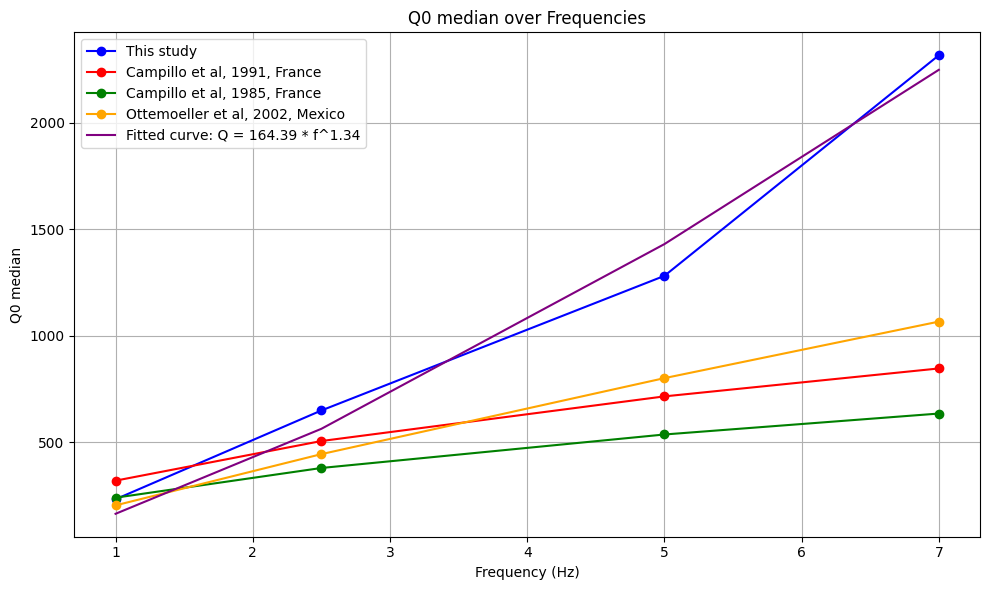

In [106]:
from scipy.optimize import curve_fit

def power_law(frequency, a, b):
    return a * frequency**b




fmins = [0.5, 2, 4,6]
fmaxs = [1.5, 3, 6,8]
Q_mean = {}
for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    Q0_Sk_dict = Lg_Q0_Sk(mini, maxi, plot_Q0=False, plot_Sk=False)
    Q0_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]
    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q_mean"] for data in Q_mean.values()]




frequencies = np.array([float(freq.split()[0]) for freq in Q_mean.keys()])
campillo_1991 = 320 * frequencies ** 0.5
campillo_1985 = 240 * frequencies ** 0.5
ottemoeller_2002 = 204* frequencies ** 0.85


popt, pcov = curve_fit(power_law, frequencies, Q_mean_values)

a, b = popt
print(f"Coefficients: a = {a}, b = {b}")

fitted_Q = power_law(frequencies, a, b)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, Q_mean_values, marker='o', linestyle='-', color='blue', label='This study')
plt.plot(frequencies, campillo_1991, marker='o', linestyle='-', color='red', label='Campillo et al, 1991, France')
plt.plot(frequencies, campillo_1985, marker='o', linestyle='-', color='green', label='Campillo et al, 1985, France')
plt.plot(frequencies, ottemoeller_2002, marker='o', linestyle='-', color='orange', label='Ottemoeller et al, 2002, Mexico')
plt.plot(frequencies, fitted_Q, '-', label=f'Fitted curve: Q = {a:.2f} * f^{b:.2f}', color='purple')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q0 median')
plt.title('Q0 median over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Finding path specific Q

$$ \ln(A_{k,l} \cdot r^{0.83}) - \ln(P(f)) = \ln(S_k) - \frac{\pi \cdot f \cdot r}{Q \cdot V} $$
which has to be rewritten to find $$ Q_{k,l} $$, which is possible due to all the other terms being known. 

In [107]:
def Lg_Q_kl(fmin, fmax, Lg_dict, savefile=False):
    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)
    
    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))
    
    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)
    
    Q0_Sk_dict = Lg_Q0_Sk(fmin, fmax)
    Qkl_dict = {}
    v = 3.2
    
    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        Qkl_dict[formatted_event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "stations": {}
        }
        
        for station, amplitude in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)
            
            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break
            
            if site_effect is None or site_effect <= 0 or r == 0:
                continue
            
            f = (fmin + fmax) / 2 

            source_term = Q0_Sk_dict[formatted_event_time]['Sk']            
            Qkl = (-(np.pi * r * f) / v) * (-np.log(site_effect) - np.log(source_term) + np.log(amplitude * r**0.83))**-1
            
            Qkl_dict[formatted_event_time]["stations"][station] = {
                "Qkl": Qkl,
                "coordinates": {"latitude": lat, "longitude": lon}
            }
    
    if savefile:
        with open("../Data1/Qkl_results.json", "w") as f:
            json.dump(Qkl_dict, f, indent=4)
    
    return Qkl_dict

test_Qkl = Lg_Q_kl(0.5, 1.5, Lg_dict)

Processing complete.
Processed 209 events with Q0 and Sk values.


In [108]:
first_key = list(test_Qkl.keys())[0]
print(first_key)
print(test_Qkl[first_key])

2007_07_18T10_54_11
{'coordinates': {'latitude': 43.741, 'longitude': 15.174}, 'stations': {'FR.ANTF': {'Qkl': 136.6877691635848, 'coordinates': {'latitude': 43.5644, 'longitude': 7.1234}}, 'FR.CALF': {'Qkl': 242.01522226583648, 'coordinates': {'latitude': 43.7528, 'longitude': 6.9218}}, 'FR.ESCA': {'Qkl': 298.84534338633364, 'coordinates': {'latitude': 43.831, 'longitude': 7.3744}}, 'FR.OGAG': {'Qkl': 247.6585365225718, 'coordinates': {'latitude': 44.78784, 'longitude': 6.539745}}, 'FR.OGDI': {'Qkl': 221.75301283573833, 'coordinates': {'latitude': 44.1093, 'longitude': 6.2253}}, 'FR.SAOF': {'Qkl': 215.55172127416355, 'coordinates': {'latitude': 43.986, 'longitude': 7.5532}}, 'OE.ARSA': {'Qkl': 174.48420238110708, 'coordinates': {'latitude': 47.2505, 'longitude': 15.5232}}, 'OE.DAVA': {'Qkl': 249.1710618815513, 'coordinates': {'latitude': 47.286701, 'longitude': 9.8803}}, 'OE.KBA': {'Qkl': 213.77339934239086, 'coordinates': {'latitude': 47.0784, 'longitude': 13.3447}}, 'OE.MOA': {'Qkl'

### Plotting on a map as connecting event-station lines the Qkl


Relatively useless, since the lines are all over the place.

In [ ]:
'''
def plot_Qkl_map(Qkl_dict, fmin, fmax):
    Qkl_values = []
    for event in Qkl_dict.values():
        if 'stations' in event: 
            for station, station_data in event['stations'].items():
                Qkl = station_data.get('Qkl', None)
                if Qkl is not None and np.isfinite(Qkl):  # Filter out None and NaN values
                    Qkl_values.append(Qkl)

    if not Qkl_values:
        raise ValueError("No valid Qkl values found for plotting.")

    Qkl_values.sort()

    vmin = np.percentile(Qkl_values, 5)
    vmax = np.percentile(Qkl_values, 95)
    if vmin > vmax:
        vmin, vmax = sorted([vmin, vmax])

    colormap = LinearColormap(
        colors=["blue", "green", "yellow", "orange", "red"],
        vmin=vmin,
        vmax=vmax
    )

    latitudes = []
    longitudes = []

    for event in Qkl_dict.values():
        if 'coordinates' in event:
            event_lat = event['coordinates'].get('latitude')
            event_lon = event['coordinates'].get('longitude')
            if event_lat is not None and event_lon is not None:
                latitudes.append(event_lat)
                longitudes.append(event_lon)

        for station, station_data in event.get('stations', {}).items():
            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')
            if station_lat is not None and station_lon is not None:
                latitudes.append(station_lat)
                longitudes.append(station_lon)

    event_map = folium.Map(
        location=[np.mean(latitudes), np.mean(longitudes)],
        zoom_start=5,
        tiles="OpenStreetMap",
    )

    for event_time, event in Qkl_dict.items():
        if 'coordinates' not in event:
            continue
        event_lat = event['coordinates'].get('latitude')
        event_lon = event['coordinates'].get('longitude')

        if event_lat is None or event_lon is None:
            continue

        for station, station_data in event.get('stations', {}).items():
            Qkl = station_data.get('Qkl', None)
            if Qkl is None or not np.isfinite(Qkl):  # Skip invalid Qkl values
                continue

            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')

            folium.PolyLine(
                locations=[(event_lat, event_lon), (station_lat, station_lon)],
                color=colormap(Qkl), 
                weight=2,
                opacity=0.5,  # Set transparency
                tooltip=f"Event: {event_time}<br>Station: {station}<br>Qkl: {Qkl:.2f}"
            ).add_to(event_map)

    colormap.add_to(event_map)

    return event_map

Qkl_map = plot_Qkl_map(test_Qkl, fmin=0.5, fmax=1.5)
Qkl_map
'''

NameError: name 'LinearColormap' is not defined

### Testing the sensitivity of Q0 towards the Site term

Artificially modifying the site term to find how errors in the site term influence the measurements of Q.

In [26]:
def Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_term_bias=0.0):
    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)

    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results_real = {}
    results_biased = {}
    results_no_site_term = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue

        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue

        event_lat, event_lon = event_data[formatted_event_time]
        event_results_real = {}
        event_results_biased = {}
        event_results_no_site_term = {}

        for station, amplitude in stations.items():
            if station not in station_coords:
                continue

            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break

            if site_effect is None or site_effect <= 0:
                continue

            # Real site term calculation
            log_value_real = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(site_effect)
            event_results_real[station] = {"log_value": log_value_real, "distance_km": r}

            # Biased site term calculation
            biased_site_effect = site_effect + site_term_bias
            log_value_biased = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(biased_site_effect)
            event_results_biased[station] = {"log_value": log_value_biased, "distance_km": r}

            # No site term calculation
            log_value_no_site_term = np.log(amplitude) + (5 / 6) * np.log(r)
            event_results_no_site_term[station] = {"log_value": log_value_no_site_term, "distance_km": r}

        results_real[formatted_event_time] = event_results_real
        results_biased[formatted_event_time] = event_results_biased
        results_no_site_term[formatted_event_time] = event_results_no_site_term

    print("Processing complete.")
    return results_real, results_biased, results_no_site_term

results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(fmin=0.5, fmax=1.5, Lg_dict=Lg_dict, site_term_bias=5)


TypeError: loop of ufunc does not support argument 0 of type dict which has no callable log method

Real values for event 2011_09_25T13_17_10:
Intercept: -12.021386208680909
Slope: -0.0019073617611328612
Q factor: 514.7149975701042
Biased values for event 2011_09_25T13_17_10:
Intercept: -13.349850683965526
Slope: -0.002531470491731632
Q factor: 387.8171629704653
No site term values for event 2011_09_25T13_17_10:
Intercept: -11.387065697385767
Slope: -0.0027113066781188607
Q factor: 362.0939350645348


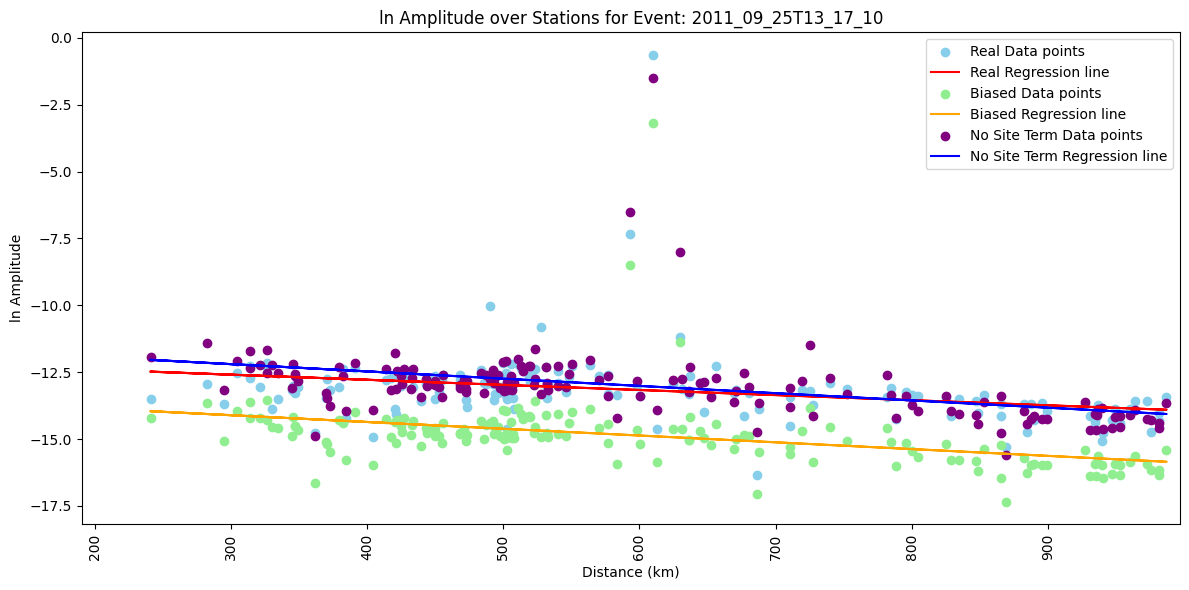

In [60]:
event_time = list(results_real.keys())[40] 
event_data_real = results_real[event_time]
event_data_biased = results_biased[event_time]
event_data_no_site_term = results_no_site_term[event_time]

# Real values
stations_real = list(event_data_real.keys())
log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]

filtered_distances_real = [d for d in distances_real if d > 200]
filtered_log_amplitudes_real = [log_amplitudes_real[i] for i in range(len(distances_real)) if distances_real[i] > 200]

slope_real, intercept_real, _, _, _ = linregress(filtered_distances_real, filtered_log_amplitudes_real)

Q_real = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_real))
print(f"Real values for event {event_time}:")
print(f"Intercept: {intercept_real}")
print(f"Slope: {slope_real}")
print(f"Q factor: {Q_real}")

# Biased values
stations_biased = list(event_data_biased.keys())
log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]

filtered_distances_biased = [d for d in distances_biased if d > 200]
filtered_log_amplitudes_biased = [log_amplitudes_biased[i] for i in range(len(distances_biased)) if distances_biased[i] > 200]

slope_biased, intercept_biased, _, _, _ = linregress(filtered_distances_biased, filtered_log_amplitudes_biased)

Q_biased = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_biased))
print(f"Biased values for event {event_time}:")
print(f"Intercept: {intercept_biased}")
print(f"Slope: {slope_biased}")
print(f"Q factor: {Q_biased}")

# No site term values
stations_no_site_term = list(event_data_no_site_term.keys())
log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]

filtered_distances_no_site_term = [d for d in distances_no_site_term if d > 200]
filtered_log_amplitudes_no_site_term = [log_amplitudes_no_site_term[i] for i in range(len(distances_no_site_term)) if distances_no_site_term[i] > 200]

slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)

Q_no_site_term = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_no_site_term))
print(f"No site term values for event {event_time}:")
print(f"Intercept: {intercept_no_site_term}")
print(f"Slope: {slope_no_site_term}")
print(f"Q factor: {Q_no_site_term}")

# Combined plot
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances_real, filtered_log_amplitudes_real, color='skyblue', label='Real Data points')
plt.plot(filtered_distances_real, intercept_real + slope_real * np.array(filtered_distances_real), color='red', label='Real Regression line')

plt.scatter(filtered_distances_biased, filtered_log_amplitudes_biased, color='lightgreen', label='Biased Data points')
plt.plot(filtered_distances_biased, intercept_biased + slope_biased * np.array(filtered_distances_biased), color='orange', label='Biased Regression line')

plt.scatter(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term, color='purple', label='No Site Term Data points')
plt.plot(filtered_distances_no_site_term, intercept_no_site_term + slope_no_site_term * np.array(filtered_distances_no_site_term), color='blue', label='No Site Term Regression line')

plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190, max(max(filtered_distances_real), max(filtered_distances_biased), max(filtered_distances_no_site_term)) + 10])
plt.title(f'ln Amplitude over Stations for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Processing complete.
Processed 209 events with Q0 and Sk values.


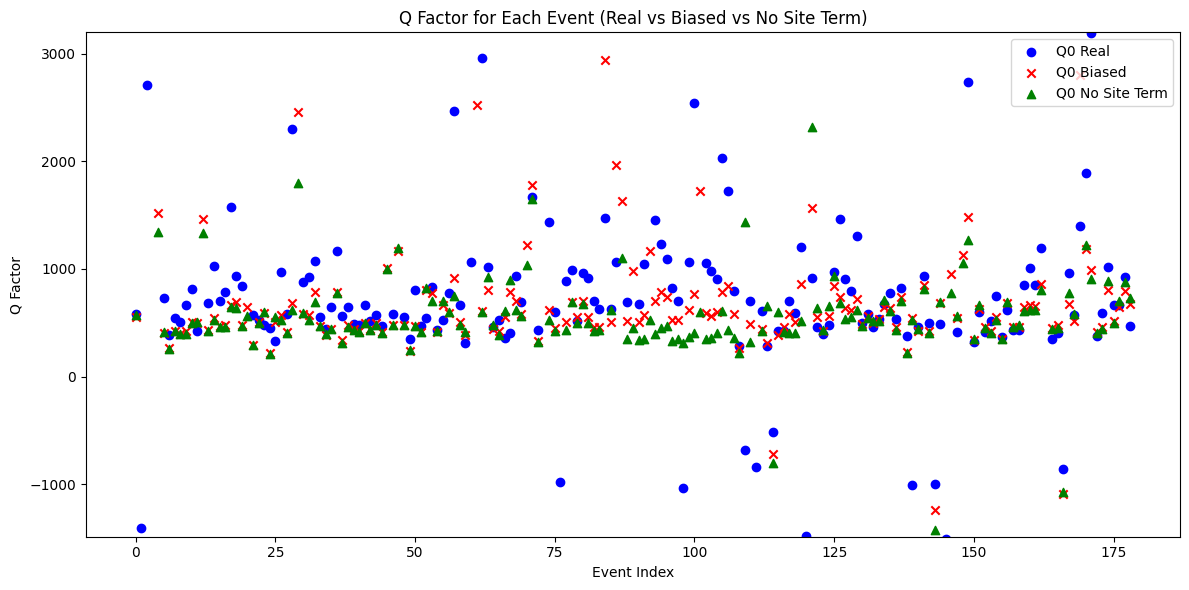

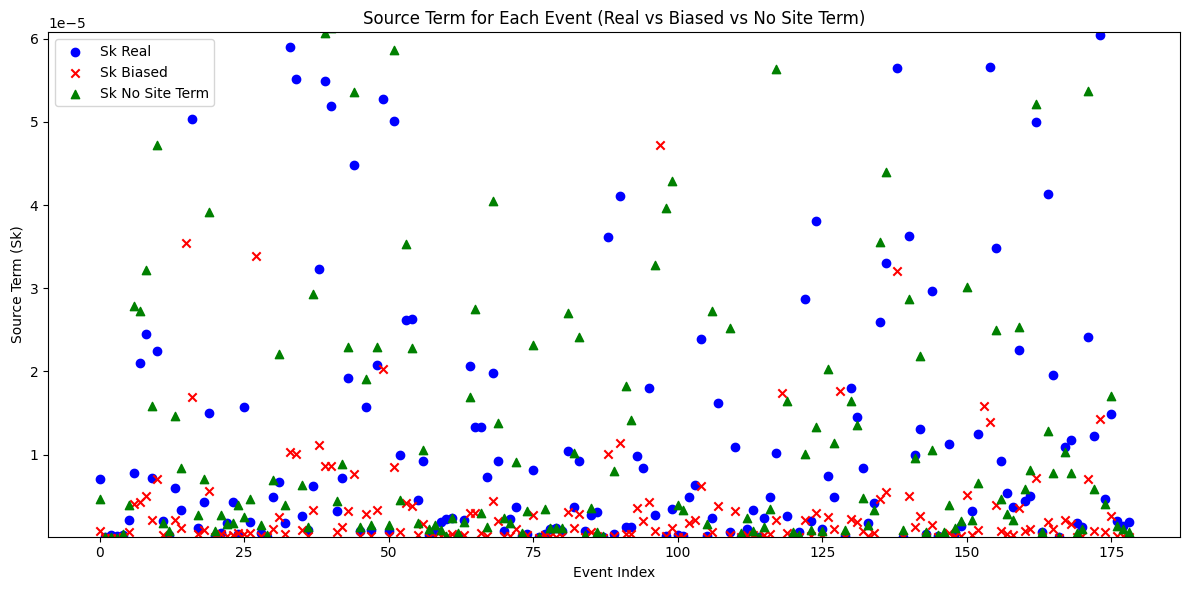

Average difference between Q0 real and Q0 biased: 1868.6201751225133
Average difference between Q0 real and Q0 no site term: 1743.509994154112


In [61]:
def Lg_Q0_Sk_biased(fmin, fmax, site_term_bias=0.1, plot_Q0=False, plot_Sk=False):
    base_directory = "/home/schreinl/Stage/Data1" 
    Lg_dict = Lg_amplitude_dict(base_directory)
    results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_term_bias=site_term_bias)

    event_data_dict = {}
    square_vals = {"Q0 real - Q0 bias": {},"Q0 real - Q0 no site term": {}, "Sk real - Sk bias": {}, "Sk real - Sk no site term": {}}
    l2_norms = {}

    for event_time, event_data_real in results_real.items():
        event_data_biased = results_biased.get(event_time, {})
        event_data_no_site_term = results_no_site_term.get(event_time, {})
        
        # Extract real data
        log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
        distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]
        filtered_distances_real = [d for d in distances_real if d > 200]
        filtered_log_amplitudes_real = [log_amplitudes_real[i] for i in range(len(distances_real)) if distances_real[i] > 200]

        # Extract biased data
        log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
        distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]
        filtered_distances_biased = [d for d in distances_biased if d > 200]
        filtered_log_amplitudes_biased = [log_amplitudes_biased[i] for i in range(len(distances_biased)) if distances_biased[i] > 200]

        # Extract no site term data
        log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
        distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]
        filtered_distances_no_site_term = [d for d in distances_no_site_term if d > 200]
        filtered_log_amplitudes_no_site_term = [log_amplitudes_no_site_term[i] for i in range(len(distances_no_site_term)) if distances_no_site_term[i] > 200]

        if len(filtered_distances_real) > 1 and len(filtered_distances_biased) > 1 and len(filtered_distances_no_site_term) > 1:
            # Real data regression
            slope_real, intercept_real, _, _, _ = linregress(filtered_distances_real, filtered_log_amplitudes_real)
            if isinstance(slope_real, (int, float)) and slope_real != 0:
                Q_real = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_real))
                Sk_real = np.exp(intercept_real)
            else:
                Q_real = None
                Sk_real = None

            # Biased data regression
            if len(filtered_distances_biased) > 1:
                slope_biased, intercept_biased, _, _, _ = linregress(filtered_distances_biased, filtered_log_amplitudes_biased)
                if isinstance(slope_biased, (int, float)) and slope_biased != 0:
                    Q_biased = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_biased))
                    Sk_biased = np.exp(intercept_biased)
                else:
                    Q_biased = None
                    Sk_biased = None
            else:
                Q_biased = None
                Sk_biased = None

            # No site term data regression
            slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)
            Q_no_site_term = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_no_site_term))
            Sk_no_site_term = np.exp(intercept_no_site_term)

            if event_time in results_with_coords:
                coordinates = results_with_coords[event_time]["coordinates"]
                event_data_dict[event_time] = {
                    "Q0_real": Q_real,
                    "Sk_real": Sk_real,
                    "Q0_biased": Q_biased,
                    "Sk_biased": Sk_biased,
                    "Q0_no_site_term": Q_no_site_term,
                    "Sk_no_site_term": Sk_no_site_term,
                    "coordinates": coordinates
                }

                if Q_real is not None and Q_biased is not None:
                    square_vals["Q0 real - Q0 bias"][event_time] = (Q_real - Q_biased) ** 2
                    
                if Q_real is not None and Q_no_site_term is not None:
                    square_vals["Q0 real - Q0 no site term"][event_time] = (Q_real - Q_no_site_term) ** 2 
                    
                if Sk_real is not None and Sk_biased is not None:
                    square_vals["Sk real - Sk bias"][event_time] = (Sk_real - Sk_biased) ** 2
                    
                if Sk_real is not None and Sk_no_site_term is not None:
                    square_vals["Sk real - Sk no site term"][event_time] = (Sk_real - Sk_no_site_term) ** 2 
                    

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")
    for norm_key, norm_values in l2_norms.items():
        valid_norms = [v for v in norm_values.values() if np.isfinite(v)]
        if valid_norms:
            print(f"L2 Norms for {norm_key}: {valid_norms}")
        else:
            print(f"L2 Norms for {norm_key}: No valid values.")
    
    for key, values in square_vals.items():
        valid_values = [v for v in values.values() if np.isfinite(v)]
        if valid_values:
            l2_norms[key] = np.sqrt(np.sum(valid_values))
        else:
            l2_norms[key] = None



    if plot_Q0 and event_data_dict:
        Q0_real_values = [data["Q0_real"] for data in event_data_dict.values() if np.isfinite(data["Q0_real"])]
        Q0_biased_values = [data["Q0_biased"] for data in event_data_dict.values() if np.isfinite(data["Q0_biased"])]
        Q0_no_site_term_values = [data["Q0_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Q0_no_site_term"])]
        
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Q0_real_values)), Q0_real_values, marker='o', color='blue', label='Q0 Real')
            plt.scatter(range(len(Q0_biased_values)), Q0_biased_values, marker='x', color='red', label='Q0 Biased')
            plt.scatter(range(len(Q0_no_site_term_values)), Q0_no_site_term_values, marker='^', color='green', label='Q0 No Site Term')
            plt.xlabel('Event Index')
            plt.ylim([np.percentile(Q0_real_values, 5), np.percentile(Q0_real_values, 95)])
            plt.ylabel('Q Factor')
            plt.title('Q Factor for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

    if plot_Sk and event_data_dict:
        Sk_real_values = [data["Sk_real"] for data in event_data_dict.values() if np.isfinite(data["Sk_real"])]
        Sk_biased_values = [data["Sk_biased"] for data in event_data_dict.values() if np.isfinite(data["Sk_biased"])]
        Sk_no_site_term_values = [data["Sk_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Sk_no_site_term"])]
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Sk_real_values)), Sk_real_values, marker='o', color='blue', label='Sk Real')
            plt.scatter(range(len(Sk_biased_values)), Sk_biased_values, marker='x', color='red', label='Sk Biased')
            plt.scatter(range(len(Sk_no_site_term_values)), Sk_no_site_term_values, marker='^', color='green', label='Sk No Site Term')
            plt.xlabel('Event Index')
            plt.ylim([np.percentile(Sk_real_values, 5), np.percentile(Sk_real_values, 95)])
            plt.ylabel('Source Term (Sk)')
            plt.title('Source Term for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

        q0_real_q0_biased_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 bias"].values() if np.isfinite(v)]
        average_diff_real_biased = np.mean(q0_real_q0_biased_diffs) if q0_real_q0_biased_diffs else None

        q0_real_q0_no_site_term_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 no site term"].values() if np.isfinite(v)]
        average_diff_real_no_site_term = np.mean(q0_real_q0_no_site_term_diffs) if q0_real_q0_no_site_term_diffs else None

        print(f"Average difference between Q0 real and Q0 biased: {average_diff_real_biased}")
        print(f"Average difference between Q0 real and Q0 no site term: {average_diff_real_no_site_term}")


    return event_data_dict, l2_norms


biased_dict, l2_norms = Lg_Q0_Sk_biased(2, 3, site_term_bias=5, plot_Q0=True, plot_Sk=True)

frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processed 209 events with Q0 and Sk values.


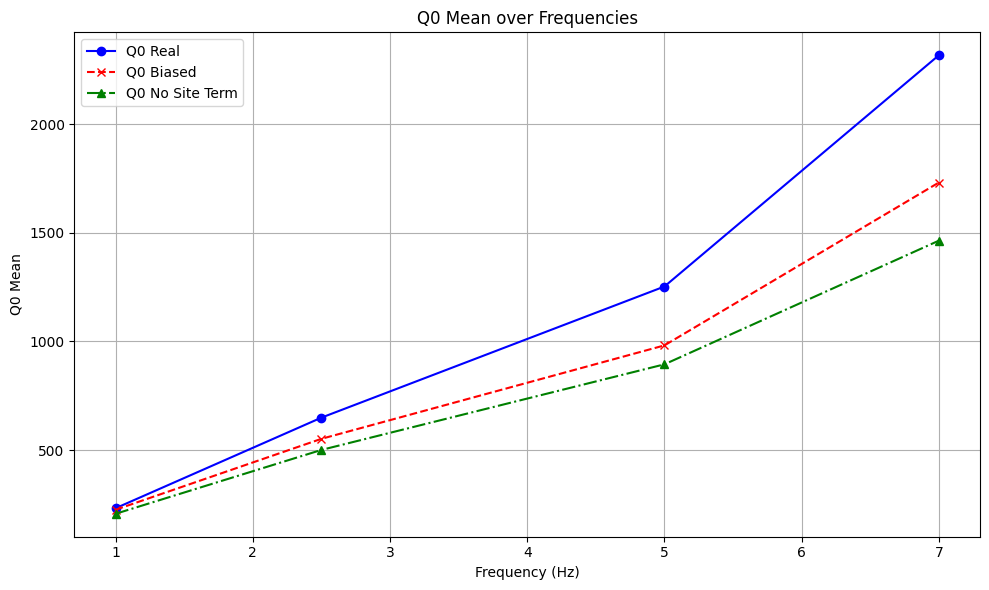

In [62]:
fmins = [0.5, 2, 4,6]
fmaxs = [1.5, 3, 6, 8]
Q_mean = {}
for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    biased_dict, l2_norms = Lg_Q0_Sk_biased(mini, maxi, site_term_bias=5)
    Q0_real_values = [data["Q0_real"] for data in biased_dict.values() if np.isfinite(data["Q0_real"])]
    Q0_biased_values = [data["Q0_biased"] for data in biased_dict.values() if np.isfinite(data["Q0_biased"])]
    Q0_no_site_term_values = [data["Q0_no_site_term"] for data in biased_dict.values() if np.isfinite(data["Q0_no_site_term"])]
    Q_mean[f'{fcenter} Hz'] = {"Q0_real": np.nanmedian(Q0_real_values), "Q0_biased": np.nanmedian(Q0_biased_values), "Q0_no_ite_term": np.nanmedian(Q0_no_site_term_values)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q0_real"] for data in Q_mean.values()]




frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q0_real_values = [data["Q0_real"] for data in Q_mean.values()]
Q0_biased_values = [data["Q0_biased"] for data in Q_mean.values()]
Q0_no_site_term_values = [data["Q0_no_ite_term"] for data in Q_mean.values()]

plt.figure(figsize=(10, 6))
plt.plot(frequencies, Q0_real_values, marker='o', linestyle='-', color='blue', label='Q0 Real')
plt.plot(frequencies, Q0_biased_values, marker='x', linestyle='--', color='red', label='Q0 Biased')
plt.plot(frequencies, Q0_no_site_term_values, marker='^', linestyle='-.', color='green', label='Q0 No Site Term')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q0 Mean')
plt.title('Q0 Mean over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
def Lg_Q0_Sk_biased(fmin, fmax, site_term_bias=0.1, plot_Q0=False, plot_Sk=False):
    base_directory = "/home/schreinl/Stage/Data1"
    Lg_dict = Lg_amplitude_dict(base_directory)
    results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_term_bias=site_term_bias)

    event_data_dict = {}
    l2_norms = {"Q0 real - Q0 bias": {}, "Q0 real - Q0 no site term": {}, "Sk real - Sk bias": {}, "Sk real - Sk no site term": {}}

    for event_time, event_data_real in results_real.items():
        event_data_biased = results_biased.get(event_time, {})
        event_data_no_site_term = results_no_site_term.get(event_time, {})
        
        def extract_filtered_data(event_data):
            log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
            distances = [station_data["distance_km"] for station_data in event_data.values()]
            return [d for d in distances if d > 200], [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

        filtered_distances_real, filtered_log_amplitudes_real = extract_filtered_data(event_data_real)
        filtered_distances_biased, filtered_log_amplitudes_biased = extract_filtered_data(event_data_biased)
        filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term = extract_filtered_data(event_data_no_site_term)

        if len(filtered_distances_real) > 1 and len(filtered_distances_biased) > 1 and len(filtered_distances_no_site_term) > 1:
            def compute_regression(distances, log_amplitudes):
                if len(distances) > 1:
                    slope, intercept, _, _, _ = linregress(distances, log_amplitudes)
                    Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope)) if slope not in [None, 0] else None
                    Sk = np.exp(intercept) if intercept is not None else None
                    return Q, Sk
                return None, None

            Q_real, Sk_real = compute_regression(filtered_distances_real, filtered_log_amplitudes_real)
            Q_biased, Sk_biased = compute_regression(filtered_distances_biased, filtered_log_amplitudes_biased)
            Q_no_site_term, Sk_no_site_term = compute_regression(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)

            if event_time in results_with_coords:
                event_data_dict[event_time] = {
                    "Q0_real": Q_real, "Sk_real": Sk_real,
                    "Q0_biased": Q_biased, "Sk_biased": Sk_biased,
                    "Q0_no_site_term": Q_no_site_term, "Sk_no_site_term": Sk_no_site_term,
                    "coordinates": results_with_coords[event_time]["coordinates"]
                }

                if Q_real is not None and Q_biased is not None:
                    l2_norms["Q0 real - Q0 bias"][event_time] = (Q_real - Q_biased) ** 2
                if Q_real is not None and Q_no_site_term is not None:
                    l2_norms["Q0 real - Q0 no site term"][event_time] = (Q_real - Q_no_site_term) ** 2
                if Sk_real is not None and Sk_biased is not None:
                    l2_norms["Sk real - Sk bias"][event_time] = (Sk_real - Sk_biased) ** 2
                if Sk_real is not None and Sk_no_site_term is not None:
                    l2_norms["Sk real - Sk no site term"][event_time] = (Sk_real - Sk_no_site_term) ** 2

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")
    for norm_key, norm_values in l2_norms.items():
        valid_norms = [v for v in norm_values.values() if np.isfinite(v)]
        if valid_norms:
            print(f"L2 Norms for {norm_key}: {np.sqrt(np.sum(valid_norms))}")
        else:
            print(f"L2 Norms for {norm_key}: No valid values.")
    
    return event_data_dict, l2_norms

biased_dict, l2_norms = Lg_Q0_Sk_biased(0.5, 1.5, site_term_bias=5, plot_Q0=True, plot_Sk=True)


Processing complete.
Processed 209 events with Q0 and Sk values.
L2 Norms for Q0 real - Q0 bias: 40918.88540227615
L2 Norms for Q0 real - Q0 no site term: 40727.42504900391
L2 Norms for Sk real - Sk bias: 0.0015318538812514903
L2 Norms for Sk real - Sk no site term: 0.022017924086865443


### Correct frequency handling 
before i believe wrong amplitudes have been used, so here is the workflow with adapted functions

In [4]:

#this one correctly reads in the amplitudes for the different frequencies

def Lg_amplitude_dict(base_directory, fmin, fmax):
    '''
    Input:
    - base_directory: str, the directory where the files are stored, mostly "/home/schreinl/Stage/Data1"
    - fmin: list of float, the minimum frequency
    - fmax: list of float, the maximum frequency

    Output:
    - Lg_dict: dict, where the keys are the event names and the values are dictionaries with station names as keys
               and the frequency bands and their amplitudes as values.
    This function reads in the Lg amplitude from all available events, and stores in a dict, where for all events the amplitude
    of all station is stored, if existent, for all the frequency ranges.
    
    Can be combined with: output_path = "..."
    with open(output_path, "w") as f:
        json.dump(Lg_dict, f, indent=4), in order to store the output file.


    '''
    events_data = {}
    
    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)
        
        if os.path.isdir(dir_path):
            event_stations = {}
            
            for f1, f2 in zip(fmin, fmax):
                frequency_range = f"{f1}_{f2}Hz" 
                filename = f"{timestamp_dir}_{frequency_range}_5_thresh_stations_with_amps.txt"
                file_path = os.path.join(dir_path, filename)
                
                if os.path.exists(file_path):
                    try:
                        with open(file_path, "r") as f:
                            data = json.load(f)
                        
                        if isinstance(data, list):
                            for entry in data:
                                if isinstance(entry, list) and len(entry) > 12:
                                    network = entry[0]
                                    station_name = entry[1]
                                    amplitude = float(entry[12])
                                    station_key = f"{network}.{station_name}"
                                    
                                    if station_key not in event_stations:
                                        event_stations[station_key] = {}
                                    
                                    event_stations[station_key][frequency_range] = amplitude
                        else:
                            print(f"Unexpected data format in file: {file_path}")
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
            
            if event_stations:
                events_data[timestamp_dir] = event_stations
    
    return events_data

fmin = [0.5, 2, 4, 6]  
fmax = [1.5,3, 6, 8] 

base_directory = "/home/schreinl/Stage/Data1"
Lg_dict = Lg_amplitude_dict(base_directory, fmin, fmax)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")



Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [5]:
def extract_frequency_range(data_dict, target_freq):
    result = {}
    for event, stations in data_dict.items():
        for station, freqs in stations.items():
            if target_freq in freqs:
                if event not in result:
                    result[event] = {}
                result[event][station] = freqs[target_freq]
    return result



testlgdict = extract_frequency_range(Lg_dict, "0.5_1.5Hz")

In [6]:


def Lg_amplitude_calculation(fmin, fmax, Lg_dict, savefile=False,special_site_terms=None):
    '''
    Input: 
        - fmin: float, the minimum frequency
        - fmax: float, the maximum frequency
        - Lg_dict: dict, the dictionary with the Lg amplitude for all events and stations, obtained by calling Lg_amplitude_dict
        - savefile: bool, if True, the output will be saved in a file
        - special_site_terms: dict, if None, the site terms will be read in from the file "../Data1/Site_effects_dict.txt"

    Output:
        - results: dict, with A_kl (the amplitude of each station and event) as well as the distance to the event
        - results_with_coords: dict, with the coordinates of the event and the stations, and their amplitude (A_kl)

    Method:
        - for each event:
        - reads in all available site terms for the given frequency range
        - calculates the A_kl for each station, using the formula:
           A_kl = ln(A_kl) + (5/6)*ln(r) - ln(site_term)
    '''
    
    if special_site_terms:
        site_terms = special_site_terms
    else:   
        with open("../Data1/Site_effects_dict.txt", "r") as f:
            site_terms = json.load(f)

    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results = {}
    Q0_calculation_terms = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        event_results = {}
        tmp = {}
        for station, freq_data in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            for freq_range, amplitude in freq_data.items():
                freq_min, freq_max = map(float, freq_range.replace("Hz", "").split("_"))
                if not (fmin <= freq_min and fmax >= freq_max):
                    continue

                site_effect = None
                for site_freq_band, site_info in site_terms.items():
                    site_freq_min, site_freq_max = map(lambda x: float(x.replace('Hz', '').strip()), site_freq_band.split('-'))
                    if freq_min <= site_freq_min <= freq_max and freq_max >= site_freq_max >= freq_min:
                        if station.split(".")[1] in site_info:
                            site_effect = site_info[station.split(".")[1]].get("median_after", None)
                            break
                
                if site_effect is None or site_effect <= 0:
                    continue 

                log_value = np.log(amplitude) + (5/6)*np.log(r) - np.log(site_effect)
                event_results[station] = {"log_value": log_value, "distance_km": r}
                tmp[station] = {'amplitude': amplitude, 'distance': r, 'site_effect': site_effect}
        
        results[formatted_event_time] = event_results
        Q0_calculation_terms[formatted_event_time] = tmp

    results_with_coords = {}
    for event_time, event_results in results.items():
        event_lat, event_lon = event_data[event_time]
        results_with_coords[event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "data": event_results
        }
    if savefile:
        with open("../Data1/processed_event_amplitudes.txt", "w") as f:
            json.dump(results, f, indent=4)
        with open("../Data1/processed_event_amplitudes_coords.txt", "w") as g:
            json.dump(results_with_coords, g, indent=4)

    print("Processing complete.")
    return results, results_with_coords


base_directory = "/home/schreinl/Stage/Data1" 
fmin_value = 0.5
fmax_value = 1.5

Lg_dict = Lg_amplitude_dict(base_directory, fmin, fmax)
results, results_with_coords = Lg_amplitude_calculation(fmin_value, fmax_value, Lg_dict, savefile=True)


Processing complete.


Intercept: -12.03814861556966
Slope: -0.0031903705951618795
for event 2012_03_15T03_29_05 the Q factor is 289.6208486538637


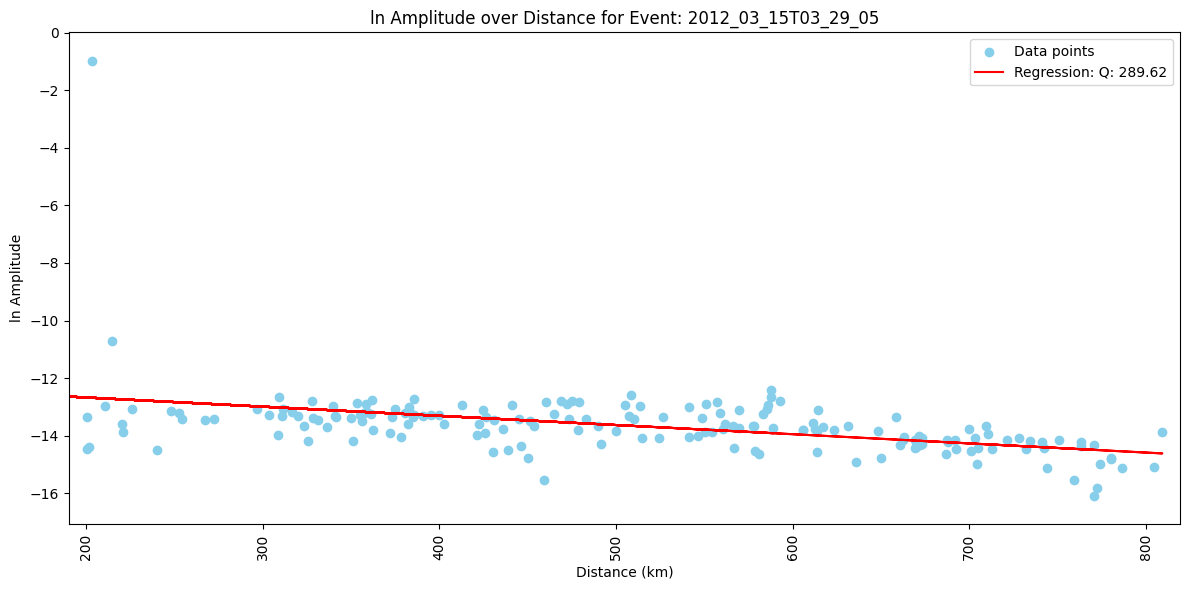

In [7]:
from scipy.stats import linregress
#event_time =  '2023_06_16T16_38_28'#  '2022_11_09T06_07_26'

event_time = list(results.keys())[47] 
#event_time = '2007_11_24T03_36_04'
event_data = results[event_time]

stations = list(event_data.keys())
log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
distances = [station_data["distance_km"] for station_data in event_data.values()]

filtered_distances = []
filtered_log_amplitudes = []

for d, a in zip(distances, log_amplitudes):
    if d > 200 and np.isfinite(d) and np.isfinite(a):
        filtered_distances.append(d)
        filtered_log_amplitudes.append(a)

filtered_distances = np.array(filtered_distances)
filtered_log_amplitudes = np.array(filtered_log_amplitudes)
slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")
Q = -(np.pi*((fmin_value+fmax_value)/2)/(3.4*slope) )
print(f'for event {event_time} the Q factor is {Q}')
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
plt.plot(distances, intercept + slope * np.array(distances), color='red', label=f'Regression: Q: {Q:.2f}')
plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190,max(filtered_distances)+10])
plt.ylim([min(filtered_log_amplitudes)-1, max(filtered_log_amplitudes)+1])
plt.title(f'ln Amplitude over Distance for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Processing complete.
209 events in total
21 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 188 events with Q0 and Sk values.


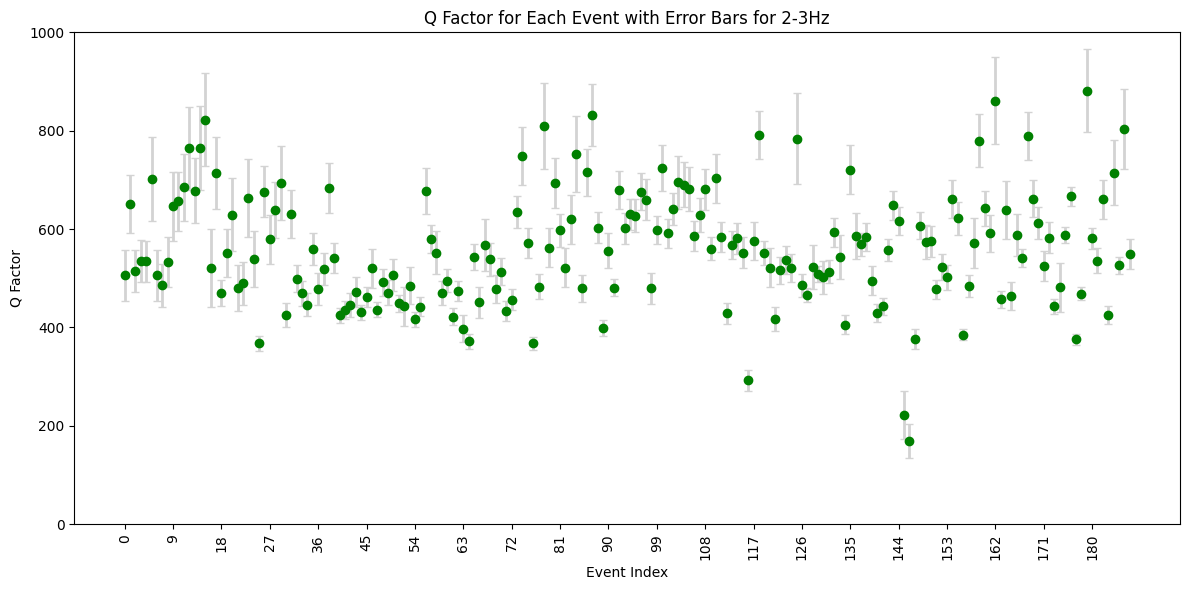

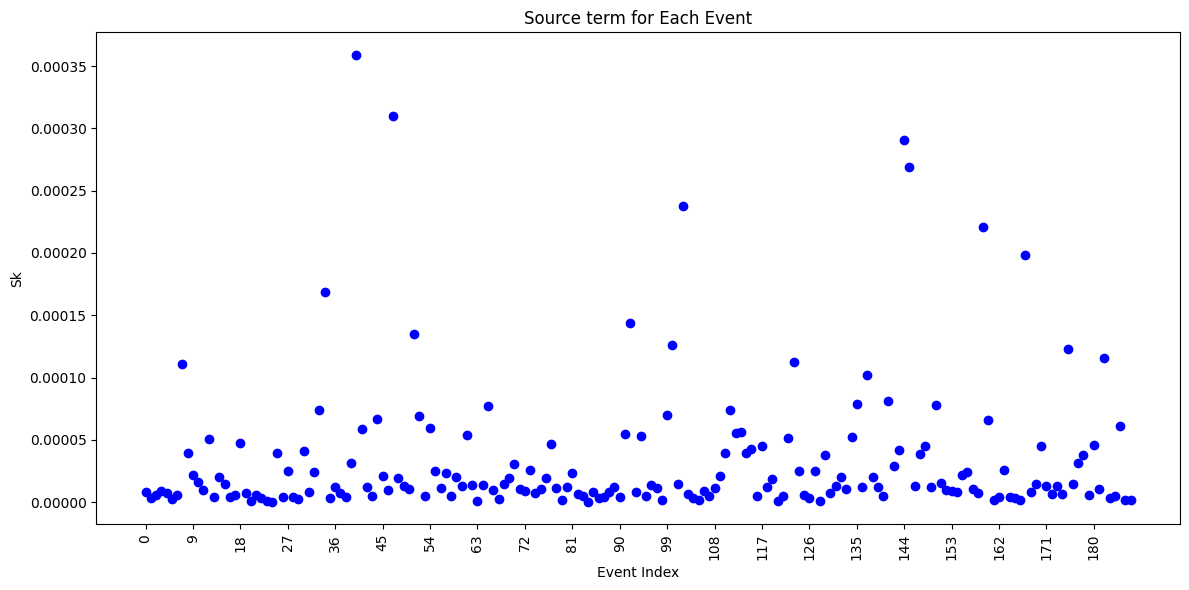

lower boundary 398.2144177993129 and upper boundary 774.38614037522
188 events on map


In [29]:
def Lg_Q0_Sk(fmin, fmax, V_Lg=3.2,plot_Q0=False, plot_Sk=False, plot_Q0_map=False, plot_Sk_map=False,special_site_terms=None,std_thresh=None,give_out_results=False):
    '''
    Input:
        - fmin: float, the minimum frequency
        - fmax: float, the maximum frequency
        - plot options: bool, if True, the plot will be shown
        - special_site_terms: dict, if you want to use a special site term, you can pass it here.
             In case the site term wants to be altered instead of read from disk.
        - std_thresh: float, if you want to set a threshold for the standard deviation of Q0, you can pass it here.
        - give_out_results: bool, if True, the function will return the results of each individual event

    Output:
        - dict with the Q0 and Sk values for all events for a single frequency range

    Method:
        - calculates, using Lg_amplitude_dict all the amplitudes of all stations for all events and frequency ranges
        - then for each event, the points of all available stations are 'plotted' against the distance
        - a linear regression is calculated, and the Q factor is calculated using the slope of the regression line, and Sk is calculated using the intercept
        - the error on Q0 and Sk is calculated using the standard error of the slope and intercept
        - if the option std_thresh is not None, events with a std higher than given threshold are not used in the above calculation
        - the results are stored in a dict, where the keys are the event times and the values are dicts with Q0, Sk and their errors
    '''





    base_directory = "/home/schreinl/Stage/Data1" 
    
    fminlist = [0.5,2,4,6]
    fmaxlist = [1.5,3,6,8]
    Lg_dict = Lg_amplitude_dict(base_directory,fminlist,fmaxlist)
    results, results_with_coords = Lg_amplitude_calculation(fmin, fmax, Lg_dict, savefile=False,special_site_terms=special_site_terms)

    event_data_dict = {}
    eventcounter = 0
    drop1counter = 0
    drop2counter = 0
    for event_time, event_data in results.items():
        eventcounter += 1
        log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
        distances = [station_data["distance_km"] for station_data in event_data.values()]

        filtered_distances = []
        filtered_log_amplitudes = []

        for d, a in zip(distances, log_amplitudes):
            if d > 200 and np.isfinite(d) and np.isfinite(a):
                filtered_distances.append(d)
                filtered_log_amplitudes.append(a)

        filtered_distances = np.array(filtered_distances)
        filtered_log_amplitudes = np.array(filtered_log_amplitudes)
        #take off outliers with IQR and z score 
        filtered_pairs = [(d, a) for d, a in zip(filtered_distances, filtered_log_amplitudes)]
        if filtered_pairs:
            filtered_distances, filtered_log_amplitudes = zip(*filtered_pairs)
            filtered_distances, filtered_log_amplitudes = remove_outliers_iqr(filtered_distances, filtered_log_amplitudes)
        else:
            filtered_distances, filtered_log_amplitudes = [], []
        if len(filtered_distances) <= 1:
            drop1counter += 1
            continue
        
        slope, intercept, r_value, p_value, std_err_slope = linregress(filtered_distances, filtered_log_amplitudes)
        if np.isnan(slope) or np.isnan(intercept):
            print(f'{event_time} is not able to produce Q')
    #else:
        #drop1counter += 1
        #print(f'{event_time} not enough data points')

        #propagate the errors, maybe for further use
        f_avg = (fmin + fmax) / 2
        Q0 = - (np.pi * f_avg) / (3.2 * slope)
        Q0_error = np.abs((np.pi * f_avg) / (V_Lg * slope**2)) * std_err_slope


        std_err_intercept = std_err_slope * np.sqrt(np.mean(np.square(filtered_distances))) 
        Sk = np.exp(intercept)
        Sk_error = Sk * std_err_intercept

        if std_thresh is not None:
            if Q0_error > std_thresh:
                drop2counter += 1
                #print(f'{event_time} skipped: Q0 error {Q0_error:.2f} exceeds threshold {std_thresh}')
                continue
            else:
                if event_time in results_with_coords:
                    coordinates = results_with_coords[event_time]["coordinates"]
                    event_data_dict[event_time] = {
                        "Q0": Q0,
                        "Q0_error": Q0_error,
                        "Sk": Sk,
                        "Sk_error": Sk_error,
                        "coordinates": coordinates
                    }
        else:
            if event_time in results_with_coords:
                    coordinates = results_with_coords[event_time]["coordinates"]
                    event_data_dict[event_time] = {
                        "Q0": Q0,
                        "Q0_error": Q0_error,
                        "Sk": Sk,
                        "Sk_error": Sk_error,
                        "coordinates": coordinates
                    }




        
    print(f'{eventcounter} events in total')
    print(f'{drop2counter} events dropped due to insufficient std on Q0')
    print(f'{drop1counter} events dropped due to insufficient data points')
    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")

    if plot_Q0 and event_data_dict:
        Q0_values = [data["Q0"] for data in event_data_dict.values()]
        Q0_errors = [data["Q0_error"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.errorbar(range(len(Q0_values)), Q0_values, yerr=Q0_errors, fmt='o', color='green', ecolor='lightgray', elinewidth=2, capsize=3)
        plt.xlabel('Event Index')
        plt.ylim([0, 1000])
        plt.ylabel('Q Factor')
        plt.title(f'Q Factor for Each Event with Error Bars for {fmin}-{fmax}Hz')
        plt.xticks(range(0, len(Q0_values), max(1, len(Q0_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Sk and event_data_dict:
        Sk_values = [data["Sk"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Sk_values)), Sk_values, marker='o', color='blue')
        plt.xlabel('Event Index')
        plt.ylabel('Sk')
        plt.title('Source term for Each Event')
        plt.xticks(range(0, len(Sk_values), max(1, len(Sk_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Q0_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Q_values = [event_data["Q0"] for event_data in event_data_dict.values()]

        unique_Q_values = sorted(set(Q for Q in Q_values if not np.isnan(Q)))
        print(f'lower boundary {np.percentile(unique_Q_values,5)} and upper boundary {np.percentile(unique_Q_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Q_values,5), 
            vmax=np.percentile(unique_Q_values,95)
        )
        colormap.caption = "Q Factor"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Q = event_data["Q0"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Q):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Q:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Q),  # Use colormap with sorted values
                    weight=1,
                    fill=True,
                    fill_color=colormap(Q),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map
        

    if plot_Sk_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Sk_values = [event_data["Sk"] for event_data in event_data_dict.values()]

        unique_Sk_values = sorted(set(Sk for Sk in Sk_values if np.isfinite(Sk)))
        print(unique_Sk_values)
        print(f'lower boundary {np.percentile(unique_Sk_values,5)} and upper boundary {np.percentile(unique_Sk_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Sk_values,5), 
            vmax=np.percentile(unique_Sk_values,95)
        )
        colormap.caption = "Source Term"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Sk = event_data["Sk"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Sk):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Sk:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Sk),
                    weight=1,
                    fill=True,
                    fill_color=colormap(Sk),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map


    if give_out_results:
        print("Returning event data dictionary.")
        return event_data_dict, results
    else:
        return event_data_dict

Q0_Sk_dict, Q0_map = Lg_Q0_Sk(2, 3,V_Lg=3.4, plot_Q0=True, plot_Sk=True,plot_Q0_map=True,std_thresh=100)
Q0_map






frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
209 events in total
22 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 187 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
209 events in total
142 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 67 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
209 events in total
180 events dropped due to insufficient std on Q0
1 events dropped due to insufficient data points
Processed 28 events with Q0 and Sk values.
[297.52301714346993, 549.3470496752332, 804.3328781266977, 732.7409266493332]
Coeffi

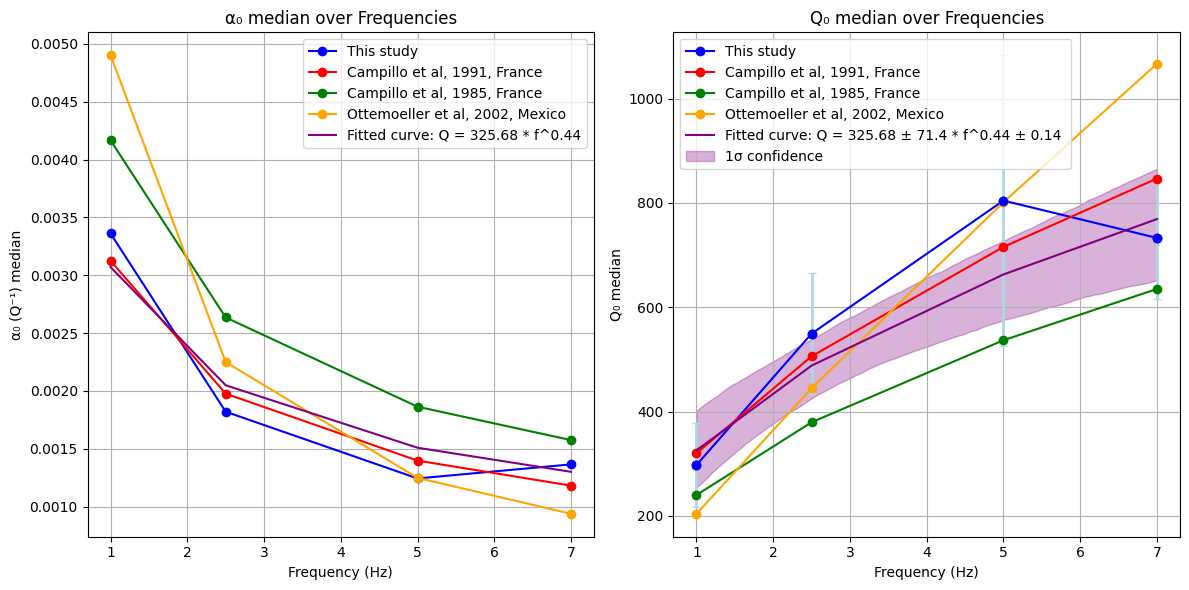

In [9]:
from scipy.optimize import curve_fit

def power_law(frequency, a, b):
    return a * frequency ** b

fmins = [0.5, 2, 4, 6]
fmaxs = [1.5, 3, 6, 8]
def Q_f(fmins,fmaxs,std_thresh=500,special_site_terms=None):



    Q_mean = {}
    for mini, maxi in zip(fmins, fmaxs):
        fcenter = (mini + maxi) / 2
        print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
        Q0_Sk_dict = Lg_Q0_Sk(mini, maxi, plot_Q0=False,special_site_terms=special_site_terms, plot_Sk=False,std_thresh=std_thresh)
        Q0_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]
        Q_mean[f'{fcenter} Hz'] = {
            "Q_mean": np.nanmedian(Q0_values),
            "Q_std": np.nanstd(Q0_values)
        }

    frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
    Q_mean_values = [data["Q_mean"] for data in Q_mean.values()]
    print(Q_mean_values)
    Q_std_values = np.array([data["Q_std"] for data in Q_mean.values()])




    frequencies = np.array([float(freq.split()[0]) for freq in Q_mean.keys()])
    campillo_1991 = 320 * frequencies ** 0.5
    campillo_1985 = 240 * frequencies ** 0.5
    ottemoeller_2002 = 204* frequencies ** 0.85


    popt, pcov = curve_fit(power_law, frequencies, Q_mean_values,sigma=Q_std_values, absolute_sigma=True, p0=[200, 0.5])

    a, b = popt
    print(f"Coefficients: a = {a}, b = {b}")
    #look at the std of each parameter whihch is the diagonal of the covariance matrix

    perr = np.sqrt(np.diag(pcov))  # standard deviation errors for a and b
    a_err, b_err = perr
    print(f"Parameter errors: Δa = {a_err}, Δb = {b_err}")



    #do monte carlo sampling to get the 1 sigma confidence interval
    f_fit = np.linspace(min(frequencies), max(frequencies), 200)

    n_samples = 1000
    samples = np.random.multivariate_normal(popt, pcov, size=n_samples)
    y_samples = np.array([power_law(f_fit, a_s, b_s) for a_s, b_s in samples])
    y_lower = np.percentile(y_samples, 16, axis=0)
    y_upper = np.percentile(y_samples, 84, axis=0)





    fitted_Q = power_law(frequencies, a, b)
    plt.figure(figsize=(12, 6))

    # plot α₀ (Q⁻¹) median
    plt.subplot(1, 2, 1)
    Q_mean_values = np.array(Q_mean_values)
    #plt.errorbar(frequencies, 1/Q_mean_values, yerr=1/Q_std_values, fmt='o', color='blue', ecolor='lightblue', elinewidth=2, capsize=3, label='This study')
    plt.plot(frequencies, 1 / Q_mean_values, marker='o', linestyle='-', color='blue', label='This study')
    plt.plot(frequencies, 1 / campillo_1991, marker='o', linestyle='-', color='red', label='Campillo et al, 1991, France')
    plt.plot(frequencies, 1 / campillo_1985, marker='o', linestyle='-', color='green', label='Campillo et al, 1985, France')
    plt.plot(frequencies, 1 / ottemoeller_2002, marker='o', linestyle='-', color='orange', label='Ottemoeller et al, 2002, Mexico')
    plt.plot(frequencies, 1 / fitted_Q, '-', label=f'Fitted curve: Q = {a:.2f} * f^{b:.2f}', color='purple')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('α₀ (Q⁻¹) median')
    plt.title('α₀ median over Frequencies')
    plt.grid(True)
    plt.legend()

    #plot Q₀ median
    plt.subplot(1, 2, 2)
    plt.errorbar(frequencies, Q_mean_values, yerr=Q_std_values, fmt='o', color='blue', ecolor='lightblue', elinewidth=2, capsize=3)
    plt.plot(frequencies, Q_mean_values, marker='o', linestyle='-', color='blue', label='This study')
    plt.plot(frequencies, campillo_1991, marker='o', linestyle='-', color='red', label='Campillo et al, 1991, France')
    plt.plot(frequencies, campillo_1985, marker='o', linestyle='-', color='green', label='Campillo et al, 1985, France')
    plt.plot(frequencies, ottemoeller_2002, marker='o', linestyle='-', color='orange', label='Ottemoeller et al, 2002, Mexico')
    plt.plot(frequencies, fitted_Q, '-', label=f'Fitted curve: Q = {a:.2f} \xb1 {a_err:.1f} * f^{b:.2f} \xb1 {b_err:.2f} ', color='purple')
    plt.fill_between(f_fit, y_lower, y_upper, color='purple', alpha=0.3, label='1σ confidence')

    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Q₀ median')
    plt.title('Q₀ median over Frequencies')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

filtered_site_effects = {}
for freq_band, stations in site_effects.items():
    filtered_site_effects[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 7
    }



Q_f(fmins,fmaxs,std_thresh=100,special_site_terms=None)

In [32]:
#this function correctly calculates the Qkl per path. 
#the output provides a dict which has key eventdate, coordinates, and stations
#the stations dict has the station name as key, and the Qkl value and station coordinates

def Lg_Q_kl(fmin, fmax, savefile=False,std_thresh=100,special_site_terms=None):
    #with open("../Data1/Site_effects_dict.txt", "r") as f:
    #    site_terms = json.load(f)
    
    if special_site_terms:
        site_terms = special_site_terms
    else: 
        site_terms = site_effect_overall(fmin, fmax, best_bet, frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax, method='multiple', map_plot=False, envelope_name='new')


    fmins = [0.5, 2, 4, 6]  
    fmaxs = [1.5,3, 6, 8] 

    base_directory = "/home/schreinl/Stage/Data1"
    Lg_dicts = Lg_amplitude_dict(base_directory, fmins, fmaxs)
    Lg_dict = extract_frequency_range(Lg_dicts, f"{fmin}_{fmax}Hz")

    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))
    
    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)
    

    Q0_Sk_dict = Lg_Q0_Sk(fmin, fmax,std_thresh=std_thresh,special_site_terms=special_site_terms)
    Qkl_dict = {}
    v = 3.2
    
    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        Qkl_dict[formatted_event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "stations": {}
        }
        
        for station, amplitude in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)
            
            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break
            
            if site_effect is None or site_effect <= 0 or r == 0:
                Qkl = None
            else:
                f = (fmin + fmax) / 2 

                if formatted_event_time in Q0_Sk_dict:
                    source_term = Q0_Sk_dict[formatted_event_time]['Sk']            
                    Qkl = (-(np.pi * r * f) / v) * (-np.log(site_effect) - np.log(source_term) + np.log(amplitude * r**0.83))**-1
                else:
                    print(f"Warning: Event time {formatted_event_time} not found in Q0_Sk_dict.")
                    Qkl = None
            
            Qkl_dict[formatted_event_time]["stations"][station] = {
                "Qkl": Qkl,
                "coordinates": {"latitude": lat, "longitude": lon}
            }
    
    if savefile:
        with open(f"../Data1/Qkl_results_{fmin}_{fmax}Hz.json", "w") as f:
            json.dump(Qkl_dict, f, indent=4)
    
    return Qkl_dict

Qkl_dict = Lg_Q_kl(2, 3, Lg_dict,std_thresh=100,special_site_terms=filtered_site_effects)
#print_keys(Qkl_dict)


Processing complete.
209 events in total
21 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 188 events with Q0 and Sk values.


#### Testing the impact of site term on attenuation Q (already done above, here again for correct frequency handling)

Here we isolate once the influence of the site term, once we introduce an artifical (systematical error) on the site term, and once we use the site term as we have calculated it. Subsequently we can also see how we increase or decrease the quality of the Q measurements, when we only use stations that have more measures for their site effect than a specific threshold. The que


In [10]:
results_original, event_results_original = Lg_Q0_Sk(0.5, 1.5, plot_Q0=False, plot_Sk=False, plot_Q0_map=False, special_site_terms=None, std_thresh=100, give_out_results=True)


Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
Returning event data dictionary.


In [33]:
freq_key = f"{0.5}-{1.5}Hz"

if freq_key not in site_effects:
    raise ValueError(f"Frequency band '{freq_key}' not found in site_effects")

base_terms = {
    station: info["median_after"]
    for station, info in site_effects[freq_key].items()
}
print(f'{len(base_terms)} stations in the frequency band {freq_key} with site terms')

special_site_terms_original = {
    freq_key: {
        station: {"median_after": value}
        for station, value in base_terms.items()
    }
}

special_site_terms_biased = {
    freq_key: {
        station: {"median_after": value + 5}
        for station, value in base_terms.items()
    }
}

special_site_terms_none = {
    freq_key: {
        station: {"median_after": 1.0}
        for station in base_terms.keys()
    }
}


print(special_site_terms_original[freq_key]['CONA'])
print(special_site_terms_biased[freq_key]['CONA'])
print(special_site_terms_none[freq_key]['CONA'])
print(len(special_site_terms_original[freq_key]))
print(len(special_site_terms_biased[freq_key]))
print(len(special_site_terms_none[freq_key]))

1992 stations in the frequency band 0.5-1.5Hz with site terms
{'median_after': 0.9549772070469895}
{'median_after': 5.95497720704699}
{'median_after': 1.0}
1992
1992
1992


1580 stations in the frequency band 2-3Hz with site terms
Running with original site terms...
Processing complete.
209 events in total
22 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 187 events with Q0 and Sk values.
Returning event data dictionary.
Running with biased site terms (+5)...
Processing complete.
209 events in total
14 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 195 events with Q0 and Sk values.
Returning event data dictionary.
Running with no site terms (set to 1.0)...
Processing complete.
209 events in total
13 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 196 events with Q0 and Sk values.
Returning event data dictionary.

Real values for event 2012_03_02T07_15_50:
Mean: -14.858632596091997, Slope: -0.004385601079938014, Intercept: -12.632768884739331, Q: 223.85704635513414

Biased values for event

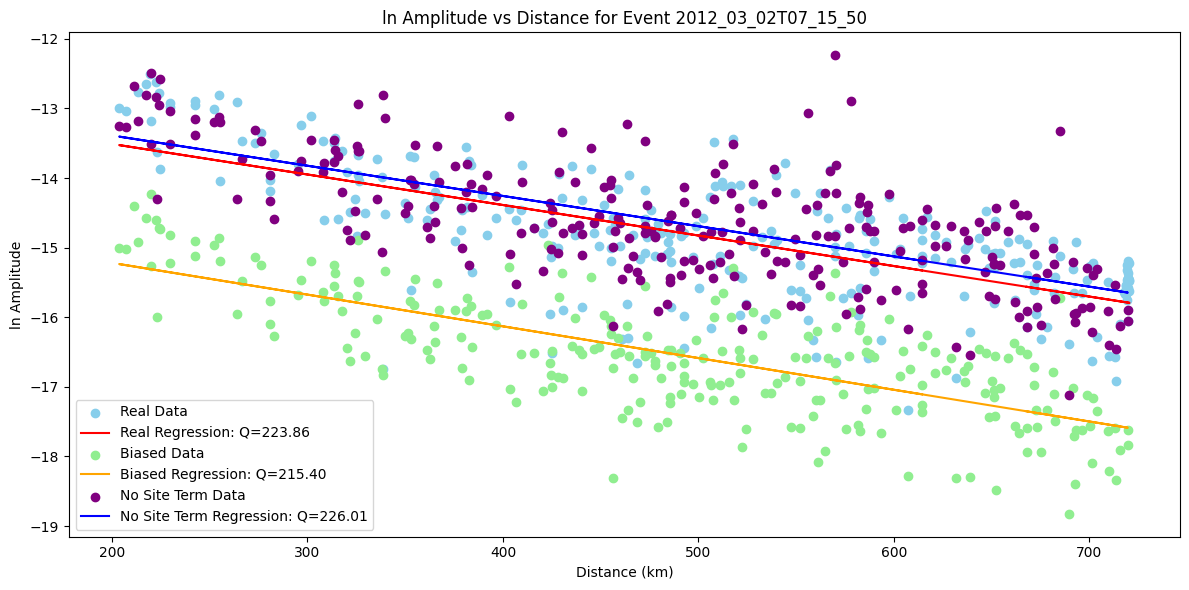

In [18]:
def run_Lg_Q0_Sk_with_site_term_variants(fmin, fmax, site_effects, std_thresh=500,plot_event_site_term=False):
    freq_key = f"{fmin}-{fmax}Hz"

    if freq_key not in site_effects:
        raise ValueError(f"Frequency band '{freq_key}' not found in site_effects")

    base_terms = {
        station: info["median_after"]
        for station, info in site_effects[freq_key].items()
    }
    print(f'{len(base_terms)} stations in the frequency band {freq_key} with site terms')

    special_site_terms_original = {
        freq_key: {
            station: {"median_after": value}
            for station, value in base_terms.items()
        }
    }

    special_site_terms_biased = {
        freq_key: {
            station: {"median_after": value + 5}
            for station, value in base_terms.items()
        }
    }

    special_site_terms_none = {
        freq_key: {
            station: {"median_after": 1.0}
            for station in base_terms.keys()
        }
    }




    #Q0_Sk_dict = Lg_Q0_Sk(mini, maxi, plot_Q0=False, plot_Sk=False,std_thresh=std_thresh)
    #Q0_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]


    print("Running with original site terms...")
    results_original, event_results_original = Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                special_site_terms=all_site_terms,std_thresh=std_thresh, give_out_results=True)
    print("Running with biased site terms (+5)...")
    results_biased,event_results_biased = Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                               special_site_terms=special_site_terms_biased,
                               std_thresh=std_thresh, give_out_results=True)

    print("Running with no site terms (set to 1.0)...")
    results_no_terms,event_results_no_terms = Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                 special_site_terms=special_site_terms_none,
                                 std_thresh=std_thresh, give_out_results=True)


    if plot_event_site_term:
        plot_Q_sensitivity_per_event(44,event_results_original, event_results_biased, event_results_no_terms)
        





    return {
        "original": results_original,
        "biased": results_biased,
        "none": results_no_terms
    }, event_results_original



Qs_dicts, test_results = run_Lg_Q0_Sk_with_site_term_variants(2, 3, site_effects,std_thresh=100,plot_event_site_term=True)

In [19]:
print(len(Qs_dicts["original"]))
print(len(Qs_dicts["biased"]))
print(len(Qs_dicts["none"]))

#some distributions can not be fitted --- why??

187
195
196


Number of common events across all configs: 181
median using original site terms: 551.1150003856708
median using biased site terms: 500.5332433542362
median using none site terms: 484.935220876226


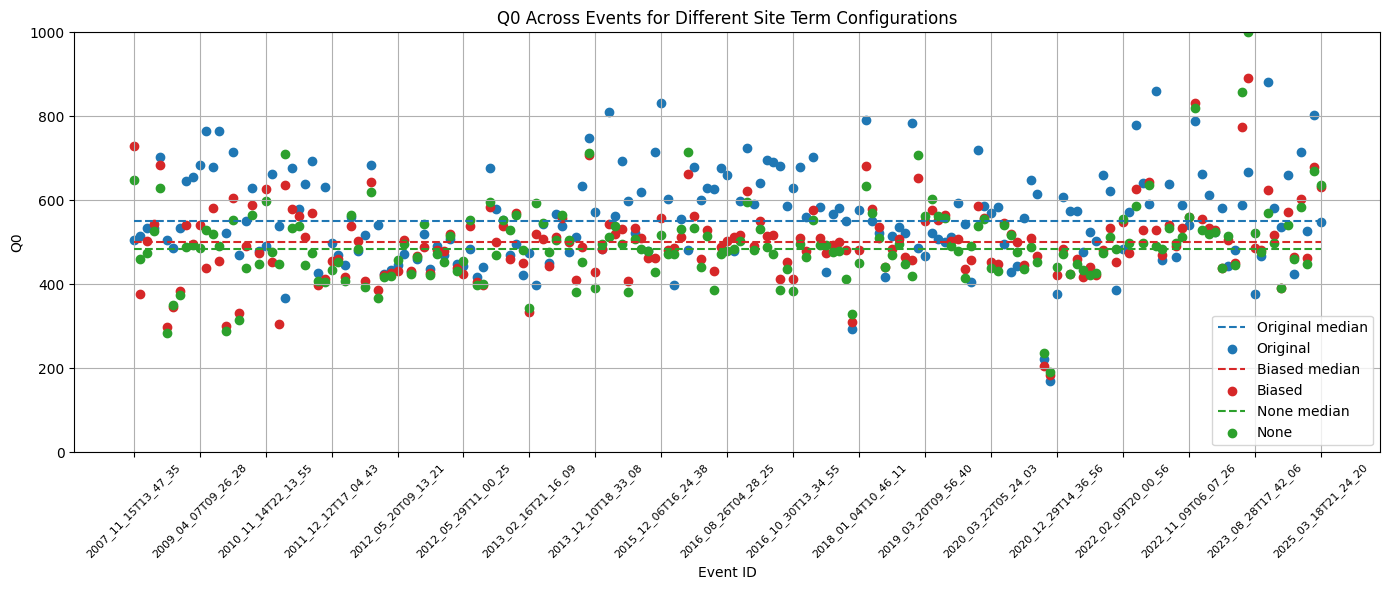

In [ ]:

def plot_Q0_across_events(Qs_dicts,configs,colors):
    '''
    plot the Q0 values for each event for different configurations.
    Input: Qs_dicts, which is the output from run_Lg_Q0_Sk_with_site_term_variants()
    '''
    event_sets = [set(Qs_dicts[c].keys()) for c in configs]
    common_event_ids = sorted(set.intersection(*event_sets))

    print(f"Number of common events across all configs: {len(common_event_ids)}")

    plt.figure(figsize=(14, 6))

    for config in configs:
        Q0_values = [Qs_dicts[config][eid]['Q0'] for eid in common_event_ids]
        print(f'median using {config} site terms: {np.nanmedian(Q0_values)}')
        plt.hlines(np.nanmedian(Q0_values), xmin=0, xmax=len(common_event_ids) - 1, color=colors[config], linestyle='--', label=f'{config.capitalize()} median')
        plt.scatter(common_event_ids, Q0_values, marker='o', label=config.capitalize(), color=colors[config])

    plt.xlabel('Event ID')
    plt.ylabel('Q0')
    plt.title('Q0 Across Events for Different Site Term Configurations')
    plt.legend()
    plt.grid(True)
    plt.ylim([0, 1000])
    step = 10
    xticks = list(range(0, len(common_event_ids), step))
    xtick_labels = [common_event_ids[i] for i in xticks]
    plt.xticks(xticks, xtick_labels, rotation=45, fontsize=8)

    plt.tight_layout()
    plt.show()

configs = ['original', 'biased', 'none']
colors = {'original': 'tab:blue', 'biased': 'tab:red', 'none': 'tab:green'}
#configs = ['biased']
#colors = {'biased': 'tab:red'}
plot_Q0_across_events(Qs_dicts, configs, colors)


Running for 0.5-1.5 Hz...
1992 stations in the frequency band 0.5-1.5Hz with site terms
Running with original site terms...
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
Returning event data dictionary.
Running with biased site terms (+5)...
Processing complete.
209 events in total
24 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 179 events with Q0 and Sk values.
Returning event data dictionary.
Running with no site terms (set to 1.0)...
Processing complete.
209 events in total
32 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 171 events with Q0 and Sk values.
Returning event data dictionary.
median using original site terms: 295.15225942885127
median using biased site terms: 308.47703561448026
median using none site terms: 324.3957616426

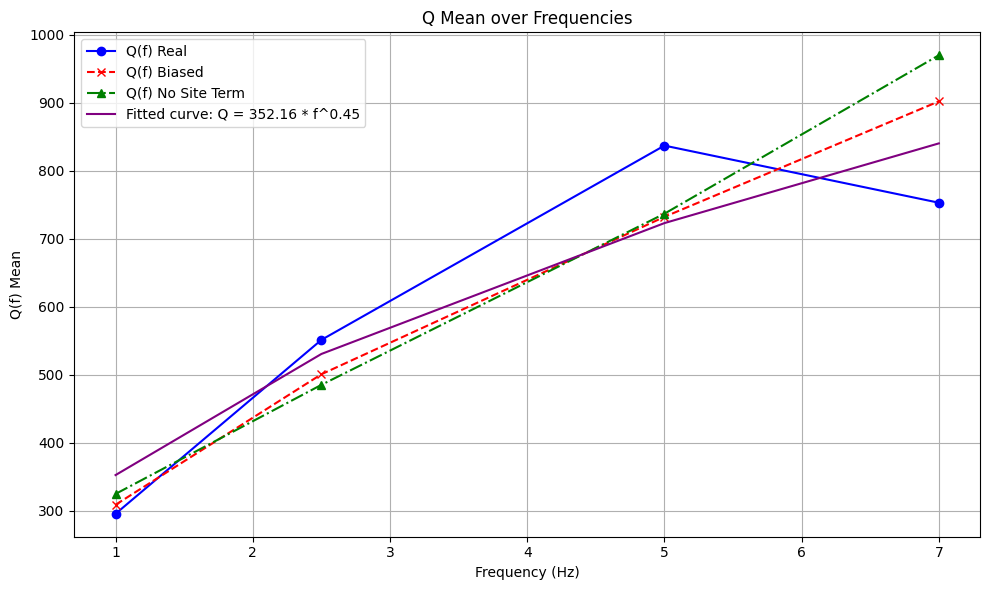

In [21]:
frequency_ranges = [(0.5, 1.5), (2,3), (4, 6),(6, 8)]

Qs_by_band = {}

for fmin, fmax in frequency_ranges:
    print(f"\nRunning for {fmin}-{fmax} Hz...")
    Qs_dicts, _ = run_Lg_Q0_Sk_with_site_term_variants(fmin, fmax, site_effects,std_thresh=100, plot_event_site_term=False)
    configs = ['original', 'biased', 'none']

    event_sets = [set(Qs_dicts[c].keys()) for c in configs]
    common_event_ids = sorted(set.intersection(*event_sets))
    Qs_by_band[f"{fmin}-{fmax}Hz"] = {}
    for config in configs:
        Q0_values = [Qs_dicts[config][eid]['Q0'] for eid in common_event_ids]
        print(f'median using {config} site terms: {np.nanmedian(Q0_values)}')
        Qs_by_band[f"{fmin}-{fmax}Hz"][config] = np.nanmedian(Q0_values)






fmins = [0.5, 2, 4,6]
fmaxs = [1.5, 3, 6,8]

frequencies = [1,2.5,5,7]#[float(freq.split('-')[0]) for freq in Qs_by_band.keys()]
Q0_real_values = [data["original"] for data in Qs_by_band.values()]
Q0_biased_values = [data["biased"] for data in Qs_by_band.values()]
Q0_no_site_term_values = [data["none"] for data in Qs_by_band.values()]
popt, pcov = curve_fit(power_law, frequencies, Q0_real_values, p0=[200, 0.5])
a, b = popt
print(f"Coefficients: a = {a}, b = {b}")
fitted_Q = power_law(frequencies, a, b)


plt.figure(figsize=(10, 6))
plt.plot(frequencies, Q0_real_values, marker='o', linestyle='-', color='blue', label='Q(f) Real')
plt.plot(frequencies, Q0_biased_values, marker='x', linestyle='--', color='red', label='Q(f) Biased')
plt.plot(frequencies, Q0_no_site_term_values, marker='^', linestyle='-.', color='green', label='Q(f) No Site Term')
plt.plot(frequencies, fitted_Q, '-', label=f'Fitted curve: Q = {a:.2f} * f^{b:.2f}', color='purple')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Q(f) Mean')
plt.title('Q Mean over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_effects=None,site_term_bias=0.0):
    '''
    Evaluate the sensitivity of the Q estimation to variations in site terms.

    Inputs:
        - fmin, fmax: float, frequency band to analyze
        - Lg_dict: dict from `Lg_amplitude_dict`, nested by [event][station][frequency_band]
        - site_term_bias: float, optional bias to add to the site term (e.g., for testing impact)

    Outputs:
        - results_real: dict, using true site terms
        - results_biased: dict, using biased site terms
        - results_no_site_term: dict, with no site terms
    '''
    import numpy as np
    import json, csv
    from obspy import UTCDateTime
    if site_effects:
        site_terms = site_effects
    elif site_effects is None:
        with open("../Data1/Site_effects_dict.txt", "r") as f:
            site_terms = json.load(f)

    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results_real = {}
    results_biased = {}
    results_no_site_term = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue

        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue

        event_lat, event_lon = event_data[formatted_event_time]
        event_results_real = {}
        event_results_biased = {}
        event_results_no_site_term = {}

        for station, freq_data in stations.items():
            if station not in station_coords:
                continue

            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            for freq_range, amplitude in freq_data.items():
                freq_min_band, freq_max_band = map(float, freq_range.replace("Hz", "").split("_"))
                if not (fmin <= freq_min_band and fmax >= freq_max_band):
                    continue

                site_effect = None
                for site_freq_band, site_info in site_terms.items():
                    site_freq_min, site_freq_max = map(lambda x: float(x.replace('Hz', '').strip()), site_freq_band.split('-'))
                    if freq_min_band <= site_freq_min <= freq_max_band and freq_max_band >= site_freq_max >= freq_min_band:
                        if station.split(".")[1] in site_info:
                            site_effect = site_info[station.split(".")[1]].get("median_after", None)
                            break

                if site_effect is None or site_effect <= 0:
                    continue

                # Real site term
                log_value_real = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(site_effect)
                event_results_real[station] = {"log_value": log_value_real, "distance_km": r}

                # Biased site term
                biased_site_effect = site_effect + site_term_bias
                log_value_biased = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(biased_site_effect)
                event_results_biased[station] = {"log_value": log_value_biased, "distance_km": r}

                # No site term
                log_value_no_site_term = np.log(amplitude) + (5 / 6) * np.log(r)
                event_results_no_site_term[station] = {"log_value": log_value_no_site_term, "distance_km": r}

        results_real[formatted_event_time] = event_results_real
        results_biased[formatted_event_time] = event_results_biased
        results_no_site_term[formatted_event_time] = event_results_no_site_term

    print("Processing complete.")
    return results_real, results_biased, results_no_site_term


results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(0.5, 1.5, Lg_dict,  site_effects=None, site_term_bias=0.1)


Processing complete.



Real values for event 2012_03_26T03_00_17:
Mean: -12.998120450027995, Slope: -0.0032290035267462107, Intercept: -10.643854680454998, Q: 304.04045586041644

Biased values for event 2012_03_26T03_00_17:
Mean: -13.281382065655942, Slope: -0.003924767668200188, Intercept: -10.41983481176322, Q: 250.1416102158776

No site term values for event 2012_03_26T03_00_17:
Mean: -12.763542701605001, Slope: -0.0035800585468144094, Intercept: -10.22133237357367, Q: 274.2267176385661


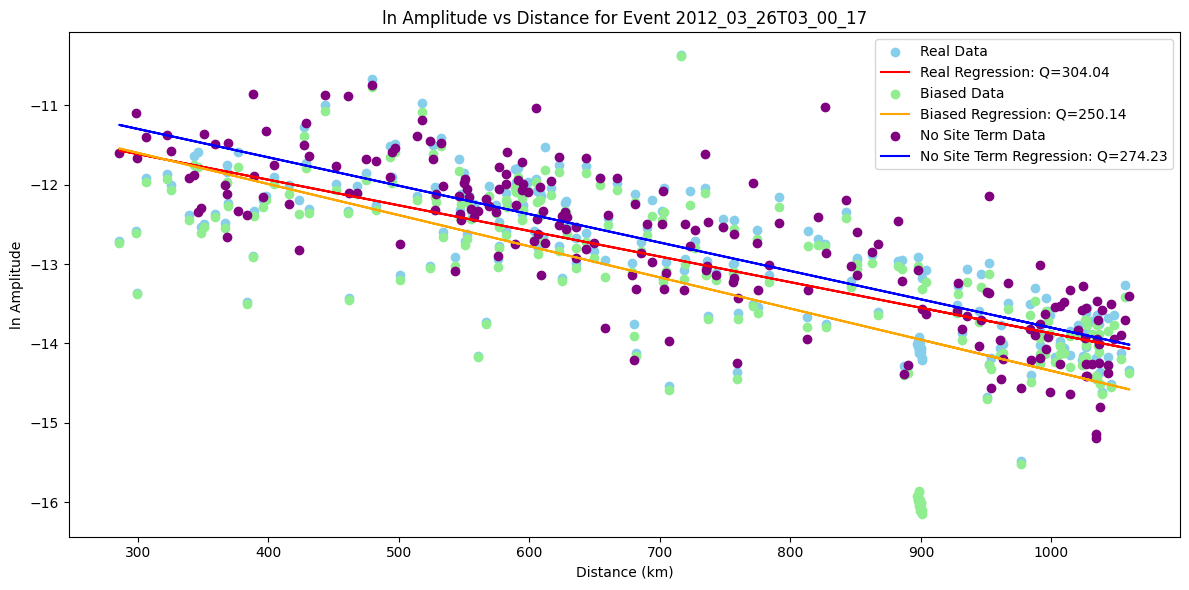

In [14]:


def remove_outliers_iqr(distances, log_amplitudes):
    distances = np.array(distances)
    log_amplitudes = np.array(log_amplitudes)
    
    Q1 = np.percentile(log_amplitudes, 25)
    Q3 = np.percentile(log_amplitudes, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (log_amplitudes >= lower_bound) & (log_amplitudes <= upper_bound)
    
    return distances[mask], log_amplitudes[mask]

def plot_Q_sensitivity_per_event(eventnumber, results_real, results_biased, results_no_site_term):
    event_time = list(results_real.keys())[eventnumber] 
    event_data_real = results_real[event_time]
    event_data_biased = results_biased[event_time]
    event_data_no_site_term = results_no_site_term[event_time]
    
    fminval = 0.5
    fmaxval = 1.5

    # --- Real values ---
    log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
    distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]
    distances_real, log_amplitudes_real = zip(*[(d, a) for d, a in zip(distances_real, log_amplitudes_real) if d > 200])
    distances_real, log_amplitudes_real = remove_outliers_iqr(distances_real, log_amplitudes_real)

    slope_real, intercept_real, _, _, _ = linregress(distances_real, log_amplitudes_real)
    Q_real = -(np.pi * ((fminval + fmaxval) / 2) / (3.2 * slope_real))

    print(f'\nReal values for event {event_time}:')
    print(f'Mean: {np.nanmean(log_amplitudes_real)}, Slope: {slope_real}, Intercept: {intercept_real}, Q: {Q_real}')

    # --- Biased values ---
    log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
    distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]
    distances_biased, log_amplitudes_biased = zip(*[(d, a) for d, a in zip(distances_biased, log_amplitudes_biased) if d > 200])
    distances_biased, log_amplitudes_biased = remove_outliers_iqr(distances_biased, log_amplitudes_biased)

    slope_biased, intercept_biased, _, _, _ = linregress(distances_biased, log_amplitudes_biased)
    Q_biased = -(np.pi * ((fminval + fmaxval) / 2) / (3.2 * slope_biased))

    print(f'\nBiased values for event {event_time}:')
    print(f'Mean: {np.nanmean(log_amplitudes_biased)}, Slope: {slope_biased}, Intercept: {intercept_biased}, Q: {Q_biased}')

    # --- No site term values ---
    log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
    distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]
    distances_no_site_term, log_amplitudes_no_site_term = zip(*[(d, a) for d, a in zip(distances_no_site_term, log_amplitudes_no_site_term) if d > 200])
    distances_no_site_term, log_amplitudes_no_site_term = remove_outliers_iqr(distances_no_site_term, log_amplitudes_no_site_term)

    slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(distances_no_site_term, log_amplitudes_no_site_term)
    Q_no_site_term = -(np.pi * ((fminval + fmaxval) / 2) / (3.2 * slope_no_site_term))

    print(f'\nNo site term values for event {event_time}:')
    print(f'Mean: {np.nanmean(log_amplitudes_no_site_term)}, Slope: {slope_no_site_term}, Intercept: {intercept_no_site_term}, Q: {Q_no_site_term}')

    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    plt.scatter(distances_real, log_amplitudes_real, color='skyblue', label='Real Data')
    plt.plot(distances_real, intercept_real + slope_real * np.array(distances_real), color='red', label=f'Real Regression: Q={Q_real:.2f}')

    plt.scatter(distances_biased, log_amplitudes_biased, color='lightgreen', label='Biased Data')
    plt.plot(distances_biased, intercept_biased + slope_biased * np.array(distances_biased), color='orange', label=f'Biased Regression: Q={Q_biased:.2f}')

    plt.scatter(distances_no_site_term, log_amplitudes_no_site_term, color='purple', label='No Site Term Data')
    plt.plot(distances_no_site_term, intercept_no_site_term + slope_no_site_term * np.array(distances_no_site_term), color='blue', label=f'No Site Term Regression: Q={Q_no_site_term:.2f}')

    plt.xlabel('Distance (km)')
    plt.ylabel('ln Amplitude')
    plt.title(f'ln Amplitude vs Distance for Event {event_time}')
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_Q_sensitivity_per_event(48, results_real, results_biased, results_no_site_term)

Processing complete.
Processed 203 events with Q0 and Sk values.


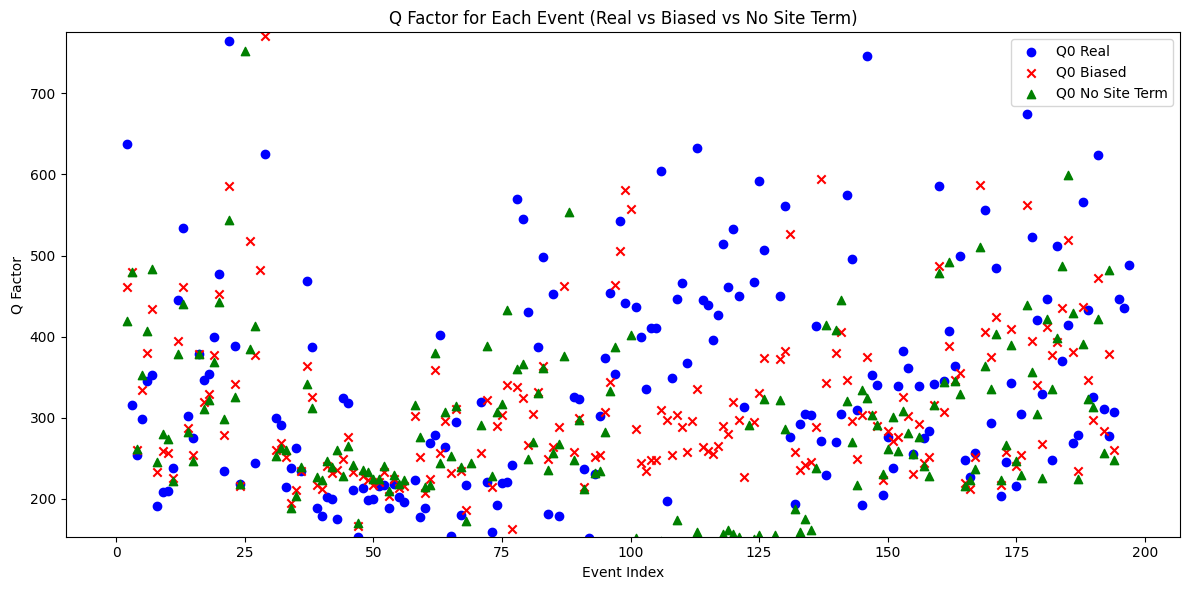

In [17]:
def Lg_Q0_Sk_biased(fmin, fmax, site_term_bias=0.1, plot_Q0=False, plot_Sk=False):
    fminlist = [0.5, 2, 4, 6]  
    fmaxlist = [1.5,3, 6, 8] 

    base_directory = "/home/schreinl/Stage/Data1"
    Lg_dict = Lg_amplitude_dict(base_directory, fminlist, fmaxlist)
    results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(0.5, 1.5, Lg_dict, site_term_bias=site_term_bias)
    event_data_dict = {}
    square_vals = {"Q0 real - Q0 bias": {},"Q0 real - Q0 no site term": {}, "Sk real - Sk bias": {}, "Sk real - Sk no site term": {}}
    l2_norms = {}

    for event_time, event_data_real in results_real.items():
        event_data_biased = results_biased.get(event_time, {})
        event_data_no_site_term = results_no_site_term.get(event_time, {})
        
        # Extract real data
        log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
        distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]
        filtered_distances_real = [d for d in distances_real if d > 200]
        filtered_log_amplitudes_real = [log_amplitudes_real[i] for i in range(len(distances_real)) if distances_real[i] > 200]

        # Extract biased data
        log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
        distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]
        filtered_distances_biased = [d for d in distances_biased if d > 200]
        filtered_log_amplitudes_biased = [log_amplitudes_biased[i] for i in range(len(distances_biased)) if distances_biased[i] > 200]

        # Extract no site term data
        log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
        distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]
        filtered_distances_no_site_term = [d for d in distances_no_site_term if d > 200]
        filtered_log_amplitudes_no_site_term = [log_amplitudes_no_site_term[i] for i in range(len(distances_no_site_term)) if distances_no_site_term[i] > 200]

        if len(filtered_distances_real) > 1 and len(filtered_distances_biased) > 1 and len(filtered_distances_no_site_term) > 1:
            # Real data regression
            slope_real, intercept_real, _, _, _ = linregress(filtered_distances_real, filtered_log_amplitudes_real)
            if isinstance(slope_real, (int, float)) and slope_real != 0:
                Q_real = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_real))
                Sk_real = np.exp(intercept_real)
            else:
                Q_real = None
                Sk_real = None

            # Biased data regression
            if len(filtered_distances_biased) > 1:
                slope_biased, intercept_biased, _, _, _ = linregress(filtered_distances_biased, filtered_log_amplitudes_biased)
                if isinstance(slope_biased, (int, float)) and slope_biased != 0:
                    Q_biased = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_biased))
                    Sk_biased = np.exp(intercept_biased)
                else:
                    Q_biased = None
                    Sk_biased = None
            else:
                Q_biased = None
                Sk_biased = None

            # No site term data regression
            slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)
            Q_no_site_term = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_no_site_term))
            Sk_no_site_term = np.exp(intercept_no_site_term)

            if event_time in results_with_coords:
                coordinates = results_with_coords[event_time]["coordinates"]
                event_data_dict[event_time] = {
                    "Q0_real": Q_real,
                    "Sk_real": Sk_real,
                    "Q0_biased": Q_biased,
                    "Sk_biased": Sk_biased,
                    "Q0_no_site_term": Q_no_site_term,
                    "Sk_no_site_term": Sk_no_site_term,
                    "coordinates": coordinates
                }

                if Q_real is not None and Q_biased is not None:
                    square_vals["Q0 real - Q0 bias"][event_time] = (Q_real - Q_biased) ** 2
                    
                if Q_real is not None and Q_no_site_term is not None:
                    square_vals["Q0 real - Q0 no site term"][event_time] = (Q_real - Q_no_site_term) ** 2 
                    
                if Sk_real is not None and Sk_biased is not None:
                    square_vals["Sk real - Sk bias"][event_time] = (Sk_real - Sk_biased) ** 2
                    
                if Sk_real is not None and Sk_no_site_term is not None:
                    square_vals["Sk real - Sk no site term"][event_time] = (Sk_real - Sk_no_site_term) ** 2 
                    

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")
    for norm_key, norm_values in l2_norms.items():
        valid_norms = [v for v in norm_values.values() if np.isfinite(v)]
        if valid_norms:
            print(f"L2 Norms for {norm_key}: {valid_norms}")
        else:
            print(f"L2 Norms for {norm_key}: No valid values.")
    
    for key, values in square_vals.items():
        valid_values = [v for v in values.values() if np.isfinite(v)]
        if valid_values:
            l2_norms[key] = np.sqrt(np.sum(valid_values))
        else:
            l2_norms[key] = None



    if plot_Q0 and event_data_dict:
        Q0_real_values = [data["Q0_real"] for data in event_data_dict.values() if np.isfinite(data["Q0_real"])]
        Q0_biased_values = [data["Q0_biased"] for data in event_data_dict.values() if np.isfinite(data["Q0_biased"])]
        Q0_no_site_term_values = [data["Q0_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Q0_no_site_term"])]
        
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Q0_real_values)), Q0_real_values, marker='o', color='blue', label='Q0 Real')
            plt.scatter(range(len(Q0_biased_values)), Q0_biased_values, marker='x', color='red', label='Q0 Biased')
            plt.scatter(range(len(Q0_no_site_term_values)), Q0_no_site_term_values, marker='^', color='green', label='Q0 No Site Term')
            plt.xlabel('Event Index')
            #plt.xlim([40,50])
            plt.ylim([np.percentile(Q0_real_values, 5), np.percentile(Q0_real_values, 95)])
            plt.ylabel('Q Factor')
            plt.title('Q Factor for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

    if plot_Sk and event_data_dict:
        Sk_real_values = [data["Sk_real"] for data in event_data_dict.values() if np.isfinite(data["Sk_real"])]
        Sk_biased_values = [data["Sk_biased"] for data in event_data_dict.values() if np.isfinite(data["Sk_biased"])]
        Sk_no_site_term_values = [data["Sk_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Sk_no_site_term"])]
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Sk_real_values)), Sk_real_values, marker='o', color='blue', label='Sk Real')
            plt.scatter(range(len(Sk_biased_values)), Sk_biased_values, marker='x', color='red', label='Sk Biased')
            plt.scatter(range(len(Sk_no_site_term_values)), Sk_no_site_term_values, marker='^', color='green', label='Sk No Site Term')
            plt.xlabel('Event Index')
            plt.ylim([np.percentile(Sk_real_values, 5), np.percentile(Sk_real_values, 95)])
            plt.ylabel('Source Term (Sk)')
            plt.title('Source Term for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

        q0_real_q0_biased_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 bias"].values() if np.isfinite(v)]
        average_diff_real_biased = np.mean(q0_real_q0_biased_diffs) if q0_real_q0_biased_diffs else None

        q0_real_q0_no_site_term_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 no site term"].values() if np.isfinite(v)]
        average_diff_real_no_site_term = np.mean(q0_real_q0_no_site_term_diffs) if q0_real_q0_no_site_term_diffs else None

        print(f"Average difference between Q0 real and Q0 biased: {average_diff_real_biased}")
        print(f"Average difference between Q0 real and Q0 no site term: {average_diff_real_no_site_term}")


    return event_data_dict, l2_norms


biased_dict, l2_norms = Lg_Q0_Sk_biased(0.5, 1.5, site_term_bias=5, plot_Q0=True, plot_Sk=False)

frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 203 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 203 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 203 events with Q0 and Sk values.


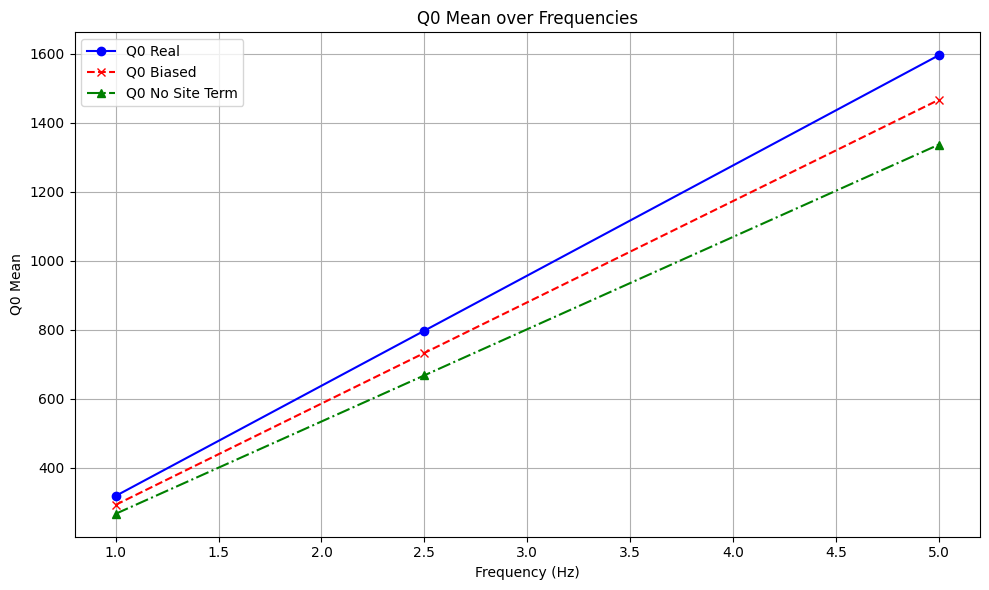

In [23]:
fmins = [0.5, 2, 4]
fmaxs = [1.5, 3, 6]
Q_mean = {}
for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    biased_dict, l2_norms = Lg_Q0_Sk_biased(mini, maxi, site_term_bias=5, plot_Q0=False, plot_Sk=False)
    Q0_real_values = [data["Q0_real"] for data in biased_dict.values() if np.isfinite(data["Q0_real"])]
    Q0_biased_values = [data["Q0_biased"] for data in biased_dict.values() if np.isfinite(data["Q0_biased"])]
    Q0_no_site_term_values = [data["Q0_no_site_term"] for data in biased_dict.values() if np.isfinite(data["Q0_no_site_term"])]
    Q_mean[f'{fcenter} Hz'] = {"Q0_real": np.nanmedian(Q0_real_values), "Q0_biased": np.nanmedian(Q0_biased_values), "Q0_no_ite_term": np.nanmedian(Q0_no_site_term_values)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q0_real"] for data in Q_mean.values()]




frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q0_real_values = [data["Q0_real"] for data in Q_mean.values()]
Q0_biased_values = [data["Q0_biased"] for data in Q_mean.values()]
Q0_no_site_term_values = [data["Q0_no_ite_term"] for data in Q_mean.values()]

plt.figure(figsize=(10, 6))
plt.plot(frequencies, Q0_real_values, marker='o', linestyle='-', color='blue', label='Q0 Real')
plt.plot(frequencies, Q0_biased_values, marker='x', linestyle='--', color='red', label='Q0 Biased')
plt.plot(frequencies, Q0_no_site_term_values, marker='^', linestyle='-.', color='green', label='Q0 No Site Term')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q0 Mean')
plt.title('Q0 Mean over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Grid search (Monte Carlo simulations) for the Site effect influence on Q

Different ways of cutting out weak site term measures will be explored. A norm has to be found which compares different site term filters and their influence on Q. A fitting norm might be the L2 norm. 
All Q should be tested against the "normal" way to produce Q. This takes all stations site term measures into account, that being said the outliers are already removed.

In [24]:
def mc_nest1(fmin, fmax,site_effects,type='bias' ,bias=0.1 ,std_thresh=500):
    '''
    this function runs the Lg_Q0_Sk function with a bias on the site terms, as well as for the normal site terms,
    for a single frequency range
    '''



    freq_key = f"{fmin}-{fmax}Hz"

    if freq_key not in site_effects:
        raise ValueError(f"Frequency band '{freq_key}' not found in site_effects")




    

    if type == 'bias':

        base_terms = {
        station: float(info["median_after"])  # Ensure conversion to float
        for station, info in site_effects[freq_key].items()
        if isinstance(info["median_after"], (int, float)) or info["median_after"].replace('.', '', 1).isdigit()
        }
        print(f'{len(base_terms)} stations in the frequency band {freq_key} with site terms')


        special_site_terms_biased = {
            freq_key: {
                station: {"median_after": value + bias}
                for station, value in base_terms.items()
            }
        }


        #the following gives all the Q0 and Sk values for the events in the frequency range
        #print("Running with original site terms...")
        results_original, event_results_original = Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                    special_site_terms=all_site_terms,
                                    std_thresh=std_thresh, give_out_results=True)
        

        #print(f"Running with biased site terms (+{bias})...")
        results_biased,event_results_biased = Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                special_site_terms=special_site_terms_biased,
                                std_thresh=std_thresh, give_out_results=True)

        #so now all we need to do is calculate the L2 norm between the Q0 points, as well as find the difference in the median of the values
        l2_vals = []
        for event, data in results_original.items():
            #print(f"Event: {event}, Q0: {data['Q0']}, Sk: {data['Sk']}")
            Q0_normal = data['Q0']
            for event1, data1 in results_biased.items():
                if event == event1:
                    Q0_biased = data1['Q0']
                    if Q0_normal is not None and Q0_biased is not None:

                        val = (Q0_normal - Q0_biased)**2
                        if not np.isnan(val):
                            #print(val)
                            l2_vals.append((Q0_normal - Q0_biased)**2)

        #l2_norm = np.sqrt(np.sum(l2_vals))
        l2_norm = np.sqrt(np.sum(l2_vals)/len(l2_vals))
        Q0_bias_mean = np.nanmedian([data["Q0"] for event, data in results_biased.items()])
        Q0_normal_mean = np.nanmedian([data["Q0"] for event, data in results_original.items()])
        return {
            "biased_Q0s": results_biased,
            "bias": bias,
            "Q0_bias_mean": Q0_bias_mean,
            "Q0_normal_mean": Q0_normal_mean,
            "Q0 difference": np.abs(Q0_bias_mean - Q0_normal_mean),
            "l2_norm": l2_norm,
        }


    if type == 'threshold':

        base_terms = {
        station: {"median_after": info["median_after"], "num_points_after": info["num_points_after"]}
        for station, info in site_effects[freq_key].items()
        }
        print(f'{len(base_terms)} stations in the frequency band {freq_key} with site terms')

        special_site_terms_thresholded = {freq_key: {
        station: {"median_after": info["median_after"]}
        for station, info in base_terms.items()
        if info.get("num_points_after", 0) >= bias and isinstance(info["median_after"], (int, float))}
        }


        #the following gives all the Q0 and Sk values for the events in the frequency range
        #print("Running with original site terms...")
        results_original, event_results_original = Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                    special_site_terms=all_site_terms,
                                    std_thresh=std_thresh, give_out_results=True)
        

        #print(f"Running with biased site terms (+{bias})...")
        results_biased, event_results_biased = Lg_Q0_Sk(fmin, fmax,plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                                special_site_terms=special_site_terms_thresholded,
                                                 std_thresh=std_thresh, give_out_results=True)

        #so now all we need to do is calculate the L2 norm between the Q0 points, as well as find the difference in the median of the values
        l2_vals = []
        for event, data in results_original.items():
            #print(f"Event: {event}, Q0: {data['Q0']}, Sk: {data['Sk']}")
            Q0_normal = data['Q0']
            for event1, data1 in results_biased.items():
                if event == event1:
                    Q0_biased = data1['Q0']
                    if Q0_normal is not None and Q0_biased is not None:

                        val = (Q0_normal - Q0_biased)**2
                        if not np.isnan(val):
                            #print(val)
                            l2_vals.append((Q0_normal - Q0_biased)**2)

        #l2_norm = np.sqrt(np.sum(l2_vals))
        #we can also use RSME instead of the absolute l2
        l2_norm = np.sqrt(np.sum(l2_vals)/len(l2_vals))

        Q0_bias_mean = np.nanmedian([data["Q0"] for event, data in results_biased.items()])
        Q0_normal_mean = np.nanmedian([data["Q0"] for event, data in results_original.items()])
        return {
            "biased_Q0s": results_biased,
            'original_Q0s': results_original,
            "bias": bias,
            "Q0_bias_mean": Q0_bias_mean,
            "Q0_normal_mean": Q0_normal_mean,
            "Q0 difference": np.abs(Q0_bias_mean - Q0_normal_mean),
            "l2_norm": l2_norm,
        }








fmin = 4
fmax = 6
site_effects = site_effect_overall(fmin,fmax,best_bet,frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax,method='multiple',map_plot=False,envelope_name='new')
bias_dict = mc_nest1(fmin, fmax, site_effects,type='threshold',bias=5,std_thresh=100)





1083 stations in the frequency band 4-6Hz with site terms
Processing complete.
209 events in total
142 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 67 events with Q0 and Sk values.
Returning event data dictionary.
Processing complete.
209 events in total
144 events dropped due to insufficient std on Q0
1 events dropped due to insufficient data points
Processed 64 events with Q0 and Sk values.
Returning event data dictionary.


751.2322715346255 791.3175228225425


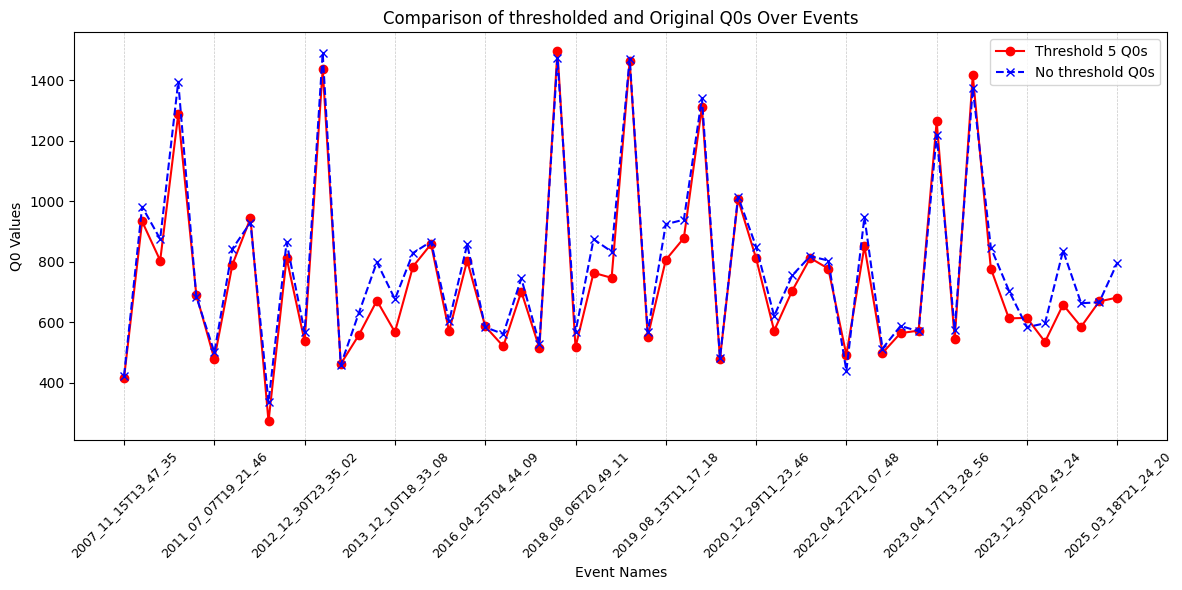

In [25]:
overlapping_events = set(bias_dict["biased_Q0s"].keys()).intersection(set(bias_dict["original_Q0s"].keys()))

biased_Q0s = [bias_dict["biased_Q0s"][event]["Q0"] for event in overlapping_events]
original_Q0s = [bias_dict["original_Q0s"][event]["Q0"] for event in overlapping_events]
print(np.nanmean(biased_Q0s), np.nanmean(original_Q0s))
sorted_events = sorted(overlapping_events)

plt.figure(figsize=(12, 6))
plt.plot(sorted_events, biased_Q0s, marker='o', linestyle='-', color='red', label='Threshold 5 Q0s')
plt.plot(sorted_events, original_Q0s, marker='x', linestyle='--', color='blue', label='No threshold Q0s')

plt.xlabel('Event Names')
plt.ylabel('Q0 Values')
plt.title('Comparison of thresholded and Original Q0s Over Events')

plt.xticks(ticks=range(0, len(sorted_events), 5), labels=[sorted_events[i] for i in range(0, len(sorted_events), 5)], rotation=45, fontsize=9)

plt.legend()
plt.grid(axis='x', which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

In [45]:
def run_bias_sweep(fmin, fmax, site_effects, bias_values,type='bias', std_thresh=100, plot=True):
    '''
    Run mc_nest1 for a range of bias values and store results.
    
    Parameters:
        fmin, fmax: frequency bounds
        site_effects: output of site_effect_overall()
        bias_values: list or array of bias values to test
        std_thresh: threshold for standard deviation
        plot: if True, will plot L2 norm vs bias
        
    Returns:
        results_dict: dictionary of results keyed by bias value
    '''
    results_dict = {}
    l2_list = []

    for bias in bias_values:
        print(f"\nRunning mc_nest1 for {type} = {bias}")
        result = mc_nest1(fmin, fmax, site_effects, type=type,bias=bias, std_thresh=std_thresh)
        results_dict[bias] = result
        l2_list.append(result["l2_norm"])

    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(bias_values, l2_list, marker='o')
        plt.xlabel(f"{type} value")
        plt.ylabel("L2 Norm between Q0s")
        plt.title(f"L2 Norm Q0 normal vs Q0 with {type} for {fmin}-{fmax} Hz")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return results_dict



Running mc_nest1 for threshold = 0
1992 stations in the frequency band 0.5-1.5Hz with site terms
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
Returning event data dictionary.
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
Returning event data dictionary.

Running mc_nest1 for threshold = 1
1992 stations in the frequency band 0.5-1.5Hz with site terms
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
Returning event data dictionary.
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events 

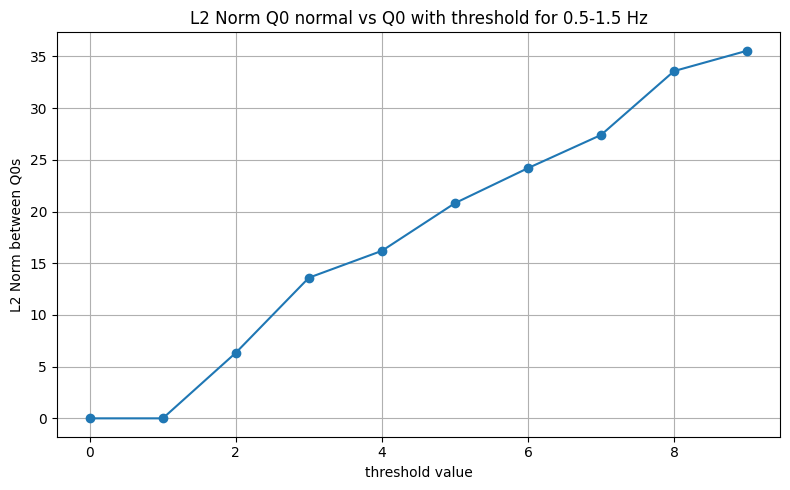

In [47]:
bias_values = np.arange(0, 10, 1)  

all_bias_dict = run_bias_sweep(fmin, fmax, site_effects, bias_values, type='threshold' ,std_thresh=100,plot=True)

#### Fais tout la manip qu'avec des stations qui ont site mesures avec plus que 3 points 

In [31]:
fmin = 2
fmax = 3
frequenciesmin = [0.5,2,4,6]
frequenciesmax = [1.5,3,6,8]
event_file='/home/schreinl/Stage/Data/big_box_4.5.csv'
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

dict_test = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", factor=1.1, fmin=fmin, fmax=fmax, data_dir='Data1',envelope_name='new')
ref_value_test = reference_stations_median(best_bet,event_file, fmin, fmax, envelope_name='new')
sites_effect_dict_test = site_effect_dict(event_file, fmin,fmax,best_bet,envelope_name='new')

site_effects = site_effect_overall(fmin,fmax,best_bet,frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax,method='multiple',map_plot=False,envelope_name='new')

filtered_site_effects = {}
for freq_band, stations in site_effects.items():
    filtered_site_effects[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 5
    }


print(len(filtered_site_effects['2-3Hz']))
carte = map_site_effect(fmin, fmax, filtered_site_effects, method='multiple')
#carte.save(f"site_effect_{(fmin+fmax)/2}_Hz_map.html")
carte



#def Q_filtered_site_term():
    

869
done reading in


stations with more than 3 points 332
stations with more than 5 points 236
frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
209 events in total
19 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 184 events with Q0 and Sk values.
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
7 events dropped due to insufficient data points
Processed 182 events with Q0 and Sk values.
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 189 events with Q0 and Sk values.
Processing complete.
209 events in total
21 events dropped due to insufficient std on Q0
0 events drop

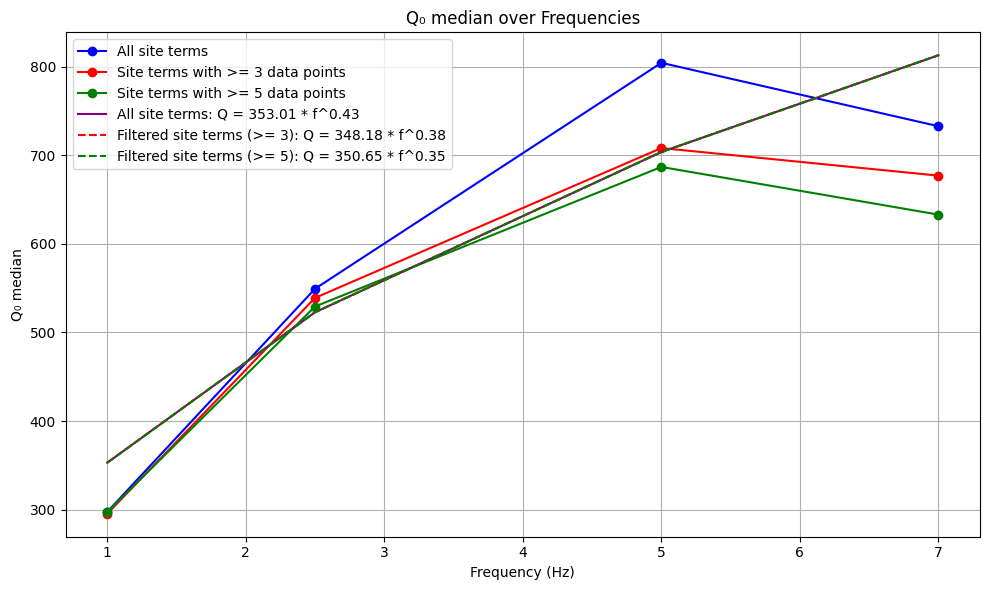

In [58]:
fmin = [0.5, 2, 4, 6]  
fmax = [1.5, 3, 6, 8] 

base_directory = "/home/schreinl/Stage/Data1" 

filtered_site_effects_3 = {}
filtered_site_effects_5 = {}

for freq_band, stations in site_effects.items():
    filtered_site_effects_3[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 3
    }
    filtered_site_effects_5[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 5
    }

print('stations with more than 3 points',len(filtered_site_effects_3[freq_band]))
print('stations with more than 5 points',len(filtered_site_effects_5[freq_band]))
# Q values filtered for site terms with >= 3 and >= 5 data points
fmins = [0.5, 2, 4, 6]
fmaxs = [1.5, 3, 6, 8]
Q_mean = {}
Q_mean_filt_3 = {}
Q_mean_filt_5 = {}


for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    
    Q0_Sk_dict_filt_3 = Lg_Q0_Sk(mini, maxi, special_site_terms=filtered_site_effects_3, std_thresh=100,plot_Q0=False, plot_Sk=False)
    Q0_Sk_dict_filt_5 = Lg_Q0_Sk(mini, maxi, special_site_terms=filtered_site_effects_5, std_thresh=100, plot_Q0=False, plot_Sk=False)
    Q0_Sk_dict = Lg_Q0_Sk(mini, maxi, special_site_terms=None, std_thresh=100, plot_Q0=False, plot_Sk=False)
    
    Q0_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]
    Q0_values_filt_3 = [event_data["Q0"] for event_data in Q0_Sk_dict_filt_3.values()]
    Q0_values_filt_5 = [event_data["Q0"] for event_data in Q0_Sk_dict_filt_5.values()]
    
    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values), "std": np.nanstd(Q0_values)}
    Q_mean_filt_3[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values_filt_3), "std": np.nanstd(Q0_values_filt_3)}
    Q_mean_filt_5[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values_filt_5), "std": np.nanstd(Q0_values_filt_5)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q_mean"] for data in Q_mean.values()]
Q_mean_values_filt_3 = [data["Q_mean"] for data in Q_mean_filt_3.values()]
Q_mean_values_filt_5 = [data["Q_mean"] for data in Q_mean_filt_5.values()]

popt, pcov = curve_fit(power_law, frequencies, Q_mean_values, p0=[200, 0.5])
popt_filt_3, pcov_filt_3 = curve_fit(power_law, frequencies, Q_mean_values_filt_3, p0=[200, 0.5])
popt_filt_5, pcov_filt_5 = curve_fit(power_law, frequencies, Q_mean_values_filt_5, p0=[200, 0.5])

a, b = popt
a_filt_3, b_filt_3 = popt_filt_3
a_filt_5, b_filt_5 = popt_filt_5

fitted_Q = power_law(frequencies, a, b)

plt.figure(figsize=(10, 6))

Q_mean_values = np.array(Q_mean_values) 
Q_mean_values_filt_3 = np.array(Q_mean_values_filt_3) 
Q_mean_values_filt_5 = np.array(Q_mean_values_filt_5) 

plt.plot(frequencies, Q_mean_values, marker='o', linestyle='-', color='blue', label='All site terms')
plt.plot(frequencies, Q_mean_values_filt_3, marker='o', linestyle='-', color='red', label='Site terms with >= 3 data points')
plt.plot(frequencies, Q_mean_values_filt_5, marker='o', linestyle='-', color='green', label='Site terms with >= 5 data points')
plt.plot(frequencies, fitted_Q, '-', label=f'All site terms: Q = {a:.2f} * f^{b:.2f}', color='purple')
plt.plot(frequencies, fitted_Q, '--', label=f'Filtered site terms (>= 3): Q = {a_filt_3:.2f} * f^{b_filt_3:.2f}', color='red')
plt.plot(frequencies, fitted_Q, '--', label=f'Filtered site terms (>= 5): Q = {a_filt_5:.2f} * f^{b_filt_5:.2f}', color='green')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q₀ median')
plt.title('Q₀ median over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 183 events with Q0 and Sk values.
Returning event data dictionary.
Processing complete.
209 events in total
19 events dropped due to insufficient std on Q0
6 events dropped due to insufficient data points
Processed 184 events with Q0 and Sk values.
Returning event data dictionary.
Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
7 events dropped due to insufficient data points
Processed 182 events with Q0 and Sk values.
Returning event data dictionary.

Original values for event 2008_03_01T07_43_13:
Mean log amplitude: -12.39
Intercept: -10.4023
Slope: -0.004064
Q factor: 241.56

Filtered 3 values for event 2008_03_01T07_43_13:
Mean log amplitude: -12.31
Intercept: -10.4696
Slope: -0.003865
Q factor: 254.01

Filtered 5 values for event 2008_03_01T07_43_13:
Mean log amplitude: -12.26
Intercept: -10.505

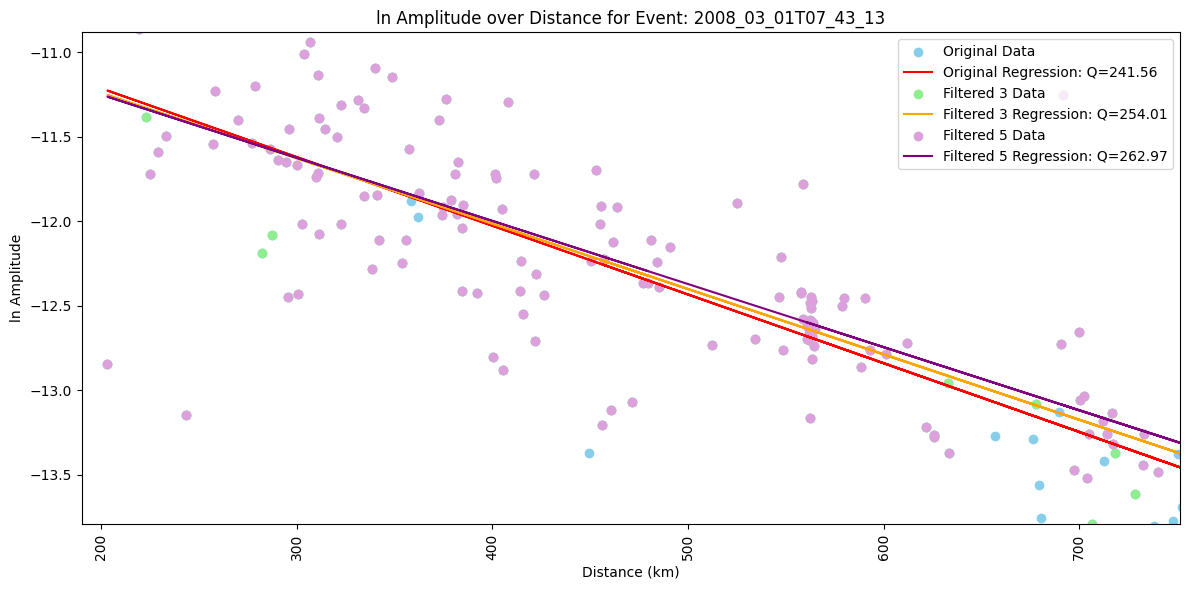

177, 163, 153


In [ ]:

results_original, event_results_original = Lg_Q0_Sk(0.5, 1.5, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                                    special_site_terms=None,
                                                    std_thresh=100, give_out_results=True)

results_filt3, event_results_filt3 = Lg_Q0_Sk(0.5, 1.5, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                             special_site_terms=filtered_site_effects_3,
                                             std_thresh=100, give_out_results=True)

results_filt5, event_results_filt5 = Lg_Q0_Sk(0.5, 1.5, plot_Q0=False, plot_Sk=False, plot_Q0_map=False,
                                             special_site_terms=filtered_site_effects_5,
                                             std_thresh=100, give_out_results=True)

eventnumber = 17
common_keys = set(event_results_original) & set(event_results_filt3) & set(event_results_filt5)
event_time = list(common_keys)[eventnumber]

event_data_real = event_results_original[event_time]
event_data_filt3 = event_results_filt3[event_time]
event_data_filt5 = event_results_filt5[event_time]

fminval = 0.5
fmaxval = 1.5

def get_filtered_data(event_data, label):
    log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
    distances = [station_data["distance_km"] for station_data in event_data.values()]
    filtered_distances = [d for d in distances if d > 200]
    filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]
    
    if len(filtered_distances) < 2:
        print(f"Not enough points for regression in {label}")
        return None, None, None, None, None
    
    slope, intercept, _, _, _ = linregress(filtered_distances, filtered_log_amplitudes)
    Q = -(np.pi * ((fminval + fmaxval) / 2) / (3.2 * slope))

    print(f"\n{label} values for event {event_time}:")
    print(f"Mean log amplitude: {np.nanmean(filtered_log_amplitudes):.2f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"Slope: {slope:.6f}")
    print(f"Q factor: {Q:.2f}")

    return filtered_distances, filtered_log_amplitudes, slope, intercept, Q

d_real, a_real, s_real, i_real, Q_real = get_filtered_data(event_data_real, "Original")
d_filt3, a_filt3, s_filt3, i_filt3, Q_filt3 = get_filtered_data(event_data_filt3, "Filtered 3")
d_filt5, a_filt5, s_filt5, i_filt5, Q_filt5 = get_filtered_data(event_data_filt5, "Filtered 5")

plt.figure(figsize=(12, 6))

if d_real:
    plt.scatter(d_real, a_real, color='skyblue', label='Original Data')
    plt.plot(d_real, i_real + s_real * np.array(d_real), color='red', label=f'Original Regression: Q={Q_real:.2f}')

if d_filt3:
    plt.scatter(d_filt3, a_filt3, color='lightgreen', label='Filtered 3 Data')
    plt.plot(d_filt3, i_filt3 + s_filt3 * np.array(d_filt3), color='orange', label=f'Filtered 3 Regression: Q={Q_filt3:.2f}')

if d_filt5:
    plt.scatter(d_filt5, a_filt5, color='plum', label='Filtered 5 Data')
    plt.plot(d_filt5, i_filt5 + s_filt5 * np.array(d_filt5), color='purple', label=f'Filtered 5 Regression: Q={Q_filt5:.2f}')

plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.title(f'ln Amplitude over Distance for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)

xlim_max = np.percentile(d_real, 98) if d_real else np.percentile(d_filt3, 98) if d_filt3 else np.percentile(d_filt5, 98)
ylim_min = np.percentile(a_filt3, 2) if a_filt3 else np.percentile(a_real, 2)
ylim_max = np.percentile(a_filt3, 98) if a_filt3 else np.percentile(a_real, 98)
plt.xlim([190, xlim_max])
plt.ylim(ylim_min, ylim_max)

plt.tight_layout()
plt.show()


print(f'{len(a_real)}, {len(a_filt3)}, {len(a_filt5)}')


In [59]:
common_values = set(a_real) & set(a_filt3)
print(f"Number of common values: {len(common_values)}")

Number of common values: 163


In [102]:
#check with Lg_amplitude_calculation if the result makes sense
fmin = [0.5, 2, 4, 6]
fmax = [1.5, 3, 6, 8]
testdict = Lg_amplitude_dict(base_directory, fmin, fmax)
fmin = 0.5
fmax = 1.5
testresults, testresultscoords = Lg_amplitude_calculation(fmin, fmax, testdict, savefile=False,special_site_terms=all_site_terms)
testresults1, testresultscoords1 = Lg_amplitude_calculation(fmin, fmax, testdict, savefile=False,special_site_terms=filtered_site_effects_3)


Processing complete.
Processing complete.


#### Spatially gridding Q

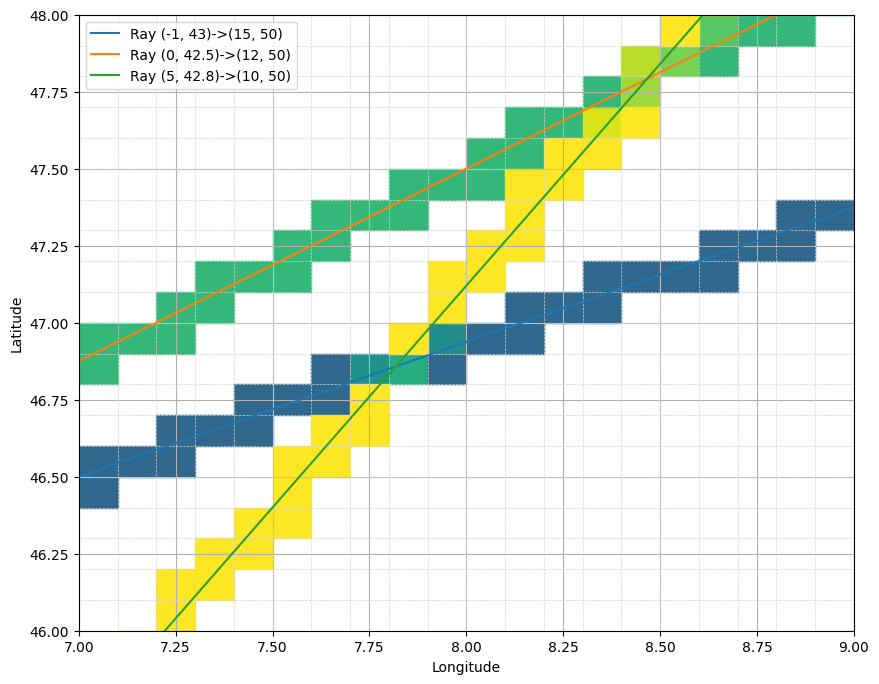

In [25]:
import numpy as np
from shapely.geometry import LineString, box
import matplotlib.pyplot as plt
from collections import defaultdict

def calculate_all_ray_paths(ray_paths, values, x_edges, y_edges):
    """
    Calculate the weighted average values for each grid cell traversed by ray paths.

    Parameters:
    - ray_paths: list of tuples, each containing (start_point, end_point).
    - values: list of floats, the value associated with each ray path.
    - x_edges: numpy array, grid x-edges.
    - y_edges: numpy array, grid y-edges.

    Returns:
    - cell_values: dict, keys are (i, j) grid indices, values are weighted averages.
    - all_ray_segments: list of tuples ((i, j), length) for plotting.
    """
    cell_contributions = defaultdict(lambda: {"total_length": 0, "weighted_sum": 0})
    all_ray_segments = []

    for (start_point, end_point), value in zip(ray_paths, values):
        line = LineString([start_point, end_point])
        for i in range(len(x_edges) - 1):
            for j in range(len(y_edges) - 1):
                cell = box(x_edges[i], y_edges[j], x_edges[i + 1], y_edges[j + 1])
                if line.intersects(cell):
                    intersection = line.intersection(cell)
                    length = intersection.length
                    if length > 0:
                        cell_contributions[(i, j)]["total_length"] += length
                        cell_contributions[(i, j)]["weighted_sum"] += value * length
                        all_ray_segments.append(((i, j), length))
                        
    cell_values = {}
    for (i, j), contrib in cell_contributions.items():
        total_length = contrib["total_length"]
        weighted_sum = contrib["weighted_sum"]
        cell_values[(i, j)] = weighted_sum / total_length if total_length > 0 else 0

    return cell_values, all_ray_segments




ray_paths = [
    ((-1, 43), (15, 50)),
    ((0, 42.5), (12, 50)),
    ((5, 42.8), (10, 50))
]
values = [10, 20, 30]  

x_edges = np.arange(-2, 16, 0.1)
y_edges = np.arange(42, 51, 0.1)

cell_values, all_ray_segments = calculate_all_ray_paths(ray_paths, values, x_edges, y_edges)

plt.figure(figsize=(10, 8))

for x_edge in x_edges:
    plt.plot([x_edge, x_edge], [y_edges[0], y_edges[-1]], color='lightgray', linestyle='--', linewidth=0.5)
for y_edge in y_edges:
    plt.plot([x_edges[0], x_edges[-1]], [y_edge, y_edge], color='lightgray', linestyle='--', linewidth=0.5)

for (start, end) in ray_paths:
    plt.plot([start[0], end[0]], [start[1], end[1]], label=f'Ray {start}->{end}')

for (i, j), value in cell_values.items():
    plt.gca().add_patch(
        plt.Rectangle(
            (x_edges[i], y_edges[j]),
            x_edges[i + 1] - x_edges[i],
            y_edges[j + 1] - y_edges[j],
            color=plt.cm.viridis(value / max(values)),
        )
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(7,9)
plt.ylim(46,48)
plt.legend()
plt.grid(True)
plt.show()


In [19]:
from shapely.geometry import LineString, box
from collections import defaultdict
from tqdm.auto import tqdm

def compute_weighted_Qkl_grid(Qkl_dict, x_edges, y_edges):
    cell_contributions = defaultdict(lambda: {"total_length": 0, "weighted_sum": 0})
    total_events = len(Qkl_dict)
    pbar = tqdm(total=total_events, desc="Processing events", unit="event")

    for event_data in Qkl_dict.values():
        event_coords = event_data["coordinates"]
        event_point = (event_coords["longitude"], event_coords["latitude"])

        for station_data in event_data["stations"].values():
            station_coords = station_data["coordinates"]
            Qkl = station_data["Qkl"]
            if Qkl is None or not np.isfinite(Qkl):
                continue
            elif Qkl < 0:
                continue
            elif Qkl > 2000:
                continue
            station_point = (station_coords["longitude"], station_coords["latitude"])

            line = LineString([event_point, station_point])

            for i in range(len(x_edges) - 1):
                for j in range(len(y_edges) - 1):
                    cell = box(x_edges[i], y_edges[j], x_edges[i+1], y_edges[j+1])
                    if line.intersects(cell):
                        intersection = line.intersection(cell)
                        length = intersection.length
                        if length > 0:
                            cell_contributions[(i, j)]["total_length"] += length
                            cell_contributions[(i, j)]["weighted_sum"] += Qkl * length

        pbar.update(1) 

    pbar.close()

    weighted_Qkl_grid = {
        cell: contrib["weighted_sum"] / contrib["total_length"]
        for cell, contrib in cell_contributions.items()
        if contrib["total_length"] > 0
    }

    return weighted_Qkl_grid


#x being fundamentally longitude?
x_edges = np.arange(-4, 17, 0.5)
#y being fundamentally latitude?
y_edges = np.arange(41, 53, 0.5)



fmin = 6
fmax = 8
Qkl_dict = Lg_Q_kl(fmin, fmax, Lg_dict)
weighted_Qkl_grid = compute_weighted_Qkl_grid(Qkl_dict, x_edges, y_edges)



#save the weighted file to avoid running this long script
output_dir = f"/home/schreinl/Stage/Data1/Grids/{fmin}/{fmax}"
os.makedirs(output_dir, exist_ok=True)

serializable_weighted_Qkl_grid = {f"{key[0]}_{key[1]}": value for key, value in weighted_Qkl_grid.items()}

with open(f"{output_dir}/{fmin}_{fmax}Hz_weighted_Qkl.txt", "w") as gridfile:
    json.dump(serializable_weighted_Qkl_grid, gridfile, indent=4)


Processing complete.
Processed 53 events with Q0 and Sk values.


Processing events: 100%|██████████| 209/209 [13:47<00:00,  3.96s/event]


In [ ]:
#load in files that have been stored

fmin = 4
fmax = 6
file_path = f"/home/schreinl/Stage/Data1/Grids/{fmin}_{fmax}Hz_weighted_Qkl.txt"

with open(file_path, "r") as gridfile:
    loaded_weighted_Qkl_grid = json.load(gridfile)
weighted_Qkl_grid = {tuple(map(int, key.split('_'))): value for key, value in loaded_weighted_Qkl_grid.items()}



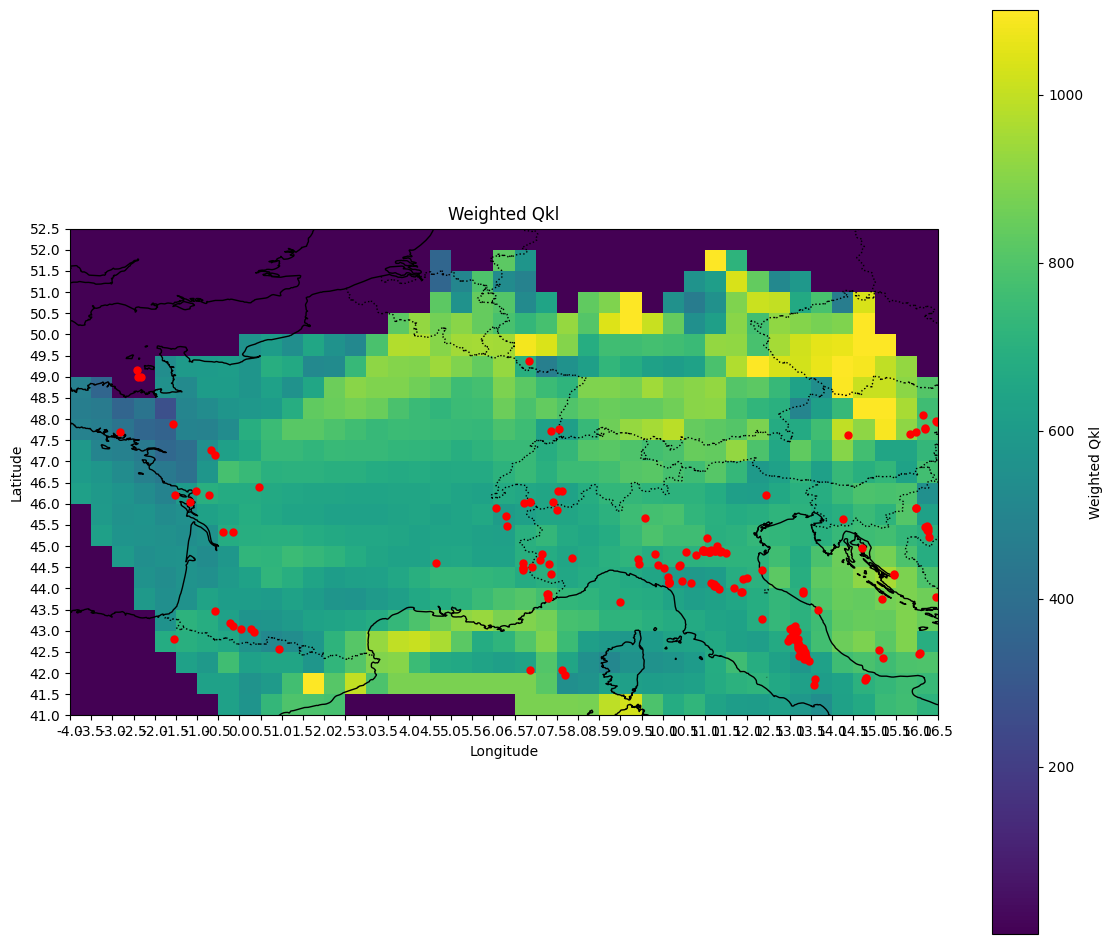

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

grid_shape = (len(y_edges) - 1, len(x_edges) - 1)
Qkl_grid = np.zeros(grid_shape)

for (i, j), contrib in weighted_Qkl_grid.items():
    Qkl_grid[j, i] = contrib

fig, ax = plt.subplots(figsize=(14, 12), subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set_extent([x_edges.min(), x_edges.max(), y_edges.min(), y_edges.max()])

c = ax.pcolormesh(x_edges, y_edges, Qkl_grid, cmap='viridis', shading='auto', vmin=1, vmax=1101)
fig.colorbar(c, ax=ax, label="Weighted Qkl")

for event_data in Qkl_dict.values():
    event_coords = event_data["coordinates"]
    ax.plot(event_coords["longitude"], event_coords["latitude"], 'ro', markersize=5)

ax.set_xticks(x_edges, crs=ccrs.PlateCarree())
ax.set_yticks(y_edges, crs=ccrs.PlateCarree())
ax.set_xticklabels([f"{x:.1f}" for x in x_edges])
ax.set_yticklabels([f"{y:.1f}" for y in y_edges])

ax.set_title("Weighted Qkl")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()
